**IMPORTs**

In [3]:
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

**FONCTIONS UTILES**

In [4]:
def add_labels(x, y, labels):
    for i in range(len(x)):
        plt.text(x[i], y[i], labels[i])

def intersection(liste1, liste2):
    return list(set(liste1) & set(liste2))

def yes_no_to_bool(yes_no):
    if yes_no.lower() in ("yes", "oui", "si"):
        return True
    elif yes_no.lower() in ("non", "no"):
        return False
    else:
        return None


def column_details(df, save_csv=False, filename="column_details.csv"):
    results = []
    
    for col in df.columns:
        series = df[col]
        dtype = series.dtype
        
        info = {
            "Colonne": col,
            "Type": dtype,
            "Nulls": series.isna().sum(),
            "Nulls_%": round(series.isna().mean() * 100, 1),
            "Min": None, "Max": None, "Moyenne": None,
            "Uniques": None, "Top_3": None
        }
        
        if dtype in ['int64', 'float64']:
            info["Min"] = series.min()
            info["Max"] = series.max()
            info["Moyenne"] = round(series.mean(), 2)
        
        elif dtype == 'object' or str(dtype) == 'category':
            info["Uniques"] = series.nunique()
            info["Top_3"] = str(series.value_counts().head(3).to_dict())
        
        elif 'datetime' in str(dtype):
            info["Min"] = series.min()
            info["Max"] = series.max()
        
        results.append(info)
        
        # Affichage console
        print(f"Colonne : {col}")
        print(f"  Type    : {dtype}")
        print(f"  Nulls   : {info['Nulls']} ({info['Nulls_%']}%)")
        if info["Min"] is not None:
            print(f"  Min     : {info['Min']}")
            print(f"  Max     : {info['Max']}")
        if info["Moyenne"] is not None:
            print(f"  Moyenne : {info['Moyenne']}")
        if info["Uniques"] is not None:
            print(f"  Uniques : {info['Uniques']}")
            print(f"  Top 3   : {info['Top_3']}")
        print()
    
    results_df = pd.DataFrame(results)
    
    if save_csv:
        results_df.to_csv(filename, index=False, encoding="utf-8-sig")
        print(f"✅ Sauvegardé dans '{filename}'")
    
    return results_df

In [5]:
student_mat = pd.read_csv("donnees/student-mat.csv")

In [6]:
student_por = pd.read_csv("donnees/student-por.csv")
student_por.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [7]:
student_mat.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [8]:
student_por.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,12,12,13
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,13,12,13
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,10,13,13
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,15,16,17
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,12,12,13


In [9]:
mat_col = student_mat.columns
por_col = student_por.columns

common = intersection(mat_col, por_col)
print(f"colonne commune : {len(common)}")

column_details(student_mat, save_csv=True, filename="column_details_mat.csv")
column_details(student_por, save_csv=True, filename="column_details_por.csv")

colonne commune : 33
Colonne : school
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : sex
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : age
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 15
  Max     : 22
  Moyenne : 16.7

Colonne : address
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : famsize
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : Pstatus
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : Medu
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 0
  Max     : 4
  Moyenne : 2.75

Colonne : Fedu
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 0
  Max     : 4
  Moyenne : 2.52

Colonne : Mjob
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : Fjob
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : reason
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : guardian
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : traveltime
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 1
  Max     : 4
  Moyenne : 1.45

Colonne : studytime
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 1
  Max 

,Colonne,Type,Nulls,Nulls_%,Min,Max,Moyenne,Uniques,Top_3
0,school,str,0,0.0,NaN,NaN,NaN,None,None
1,sex,str,0,0.0,NaN,NaN,NaN,None,None
2,age,int64,0,0.0,15.0,22.0,16.74,None,None
3,address,str,0,0.0,NaN,NaN,NaN,None,None
4,famsize,str,0,0.0,NaN,NaN,NaN,None,None
5,Pstatus,str,0,0.0,NaN,NaN,NaN,None,None
6,Medu,int64,0,0.0,0.0,4.0,2.51,None,None
7,Fedu,int64,0,0.0,0.0,4.0,2.31,None,None
8,Mjob,str,0,0.0,NaN,NaN,NaN,None,None
9,Fjob,str,0,0.0,NaN,NaN,NaN,None,None


**Introduction** *INFO*:

- Le DataFrame *Student_mat* est composé de 33 colonnes et 395 lignes de données

- Le DataFrame *Student_por* est composé de 33 colonnes et 649 lignes de données

Les deux DataFrames possèdent les même colonnes et ne possède aucune données manquantes

Pour voir les colonnes voir columns_details.md

**1ere étape** On va commencer par nettoyer les types des données de toute les données (str)

Exemple : Romantice -> yes/no => True/False

In [10]:
to_convert_bool_categorical = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian']

for col in to_convert_bool_categorical:
    student_mat[col] = pd.Categorical(student_mat[col])
for col in to_convert_bool_categorical:
    student_por[col] = pd.Categorical(student_por[col])

**Conversion de colonne en Bool**

In [11]:
to_convert_bool_col = ['schoolsup', 'famsup', 'paid', 'activities', 'higher', 'nursery', 'internet', 'romantic']

for col in to_convert_bool_col:
    student_mat[col] = student_mat[col].apply(yes_no_to_bool)

for col in to_convert_bool_col:
    student_por[col] = student_por[col].apply(yes_no_to_bool)


In [12]:
column_details(student_mat, save_csv=True, filename="column_details_mat_post_treatment.csv")

Colonne : school
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'GP': 349, 'MS': 46}

Colonne : sex
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'F': 208, 'M': 187}

Colonne : age
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 15
  Max     : 22
  Moyenne : 16.7

Colonne : address
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'U': 307, 'R': 88}

Colonne : famsize
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'GT3': 281, 'LE3': 114}

Colonne : Pstatus
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'T': 354, 'A': 41}

Colonne : Medu
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 0
  Max     : 4
  Moyenne : 2.75

Colonne : Fedu
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 0
  Max     : 4
  Moyenne : 2.52

Colonne : Mjob
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 5
  Top 3   : {'other': 141, 'services': 103, 'at_home': 59}

Colonne : Fjob
  Type    : cat

,Colonne,Type,Nulls,Nulls_%,Min,Max,Moyenne,Uniques,Top_3
0,school,category,0,0.0,NaN,NaN,NaN,2.0,"{'GP': 349, 'MS': 46}"
1,sex,category,0,0.0,NaN,NaN,NaN,2.0,"{'F': 208, 'M': 187}"
2,age,int64,0,0.0,15.0,22.0,16.70,NaN,NaN
3,address,category,0,0.0,NaN,NaN,NaN,2.0,"{'U': 307, 'R': 88}"
4,famsize,category,0,0.0,NaN,NaN,NaN,2.0,"{'GT3': 281, 'LE3': 114}"
5,Pstatus,category,0,0.0,NaN,NaN,NaN,2.0,"{'T': 354, 'A': 41}"
6,Medu,int64,0,0.0,0.0,4.0,2.75,NaN,NaN
7,Fedu,int64,0,0.0,0.0,4.0,2.52,NaN,NaN
8,Mjob,category,0,0.0,NaN,NaN,NaN,5.0,"{'other': 141, 'services': 103, 'at_home': 59}"
9,Fjob,category,0,0.0,NaN,NaN,NaN,5.0,"{'other': 217, 'services': 111, 'teacher': 29}"


In [13]:
column_details(student_por, save_csv=True, filename="column_details_por_post_treatment.csv")

Colonne : school
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'GP': 423, 'MS': 226}

Colonne : sex
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'F': 383, 'M': 266}

Colonne : age
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 15
  Max     : 22
  Moyenne : 16.74

Colonne : address
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'U': 452, 'R': 197}

Colonne : famsize
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'GT3': 457, 'LE3': 192}

Colonne : Pstatus
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'T': 569, 'A': 80}

Colonne : Medu
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 0
  Max     : 4
  Moyenne : 2.51

Colonne : Fedu
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 0
  Max     : 4
  Moyenne : 2.31

Colonne : Mjob
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 5
  Top 3   : {'other': 258, 'services': 136, 'at_home': 135}

Colonne : Fjob
  Type    :

,Colonne,Type,Nulls,Nulls_%,Min,Max,Moyenne,Uniques,Top_3
0,school,category,0,0.0,NaN,NaN,NaN,2.0,"{'GP': 423, 'MS': 226}"
1,sex,category,0,0.0,NaN,NaN,NaN,2.0,"{'F': 383, 'M': 266}"
2,age,int64,0,0.0,15.0,22.0,16.74,NaN,NaN
3,address,category,0,0.0,NaN,NaN,NaN,2.0,"{'U': 452, 'R': 197}"
4,famsize,category,0,0.0,NaN,NaN,NaN,2.0,"{'GT3': 457, 'LE3': 192}"
5,Pstatus,category,0,0.0,NaN,NaN,NaN,2.0,"{'T': 569, 'A': 80}"
6,Medu,int64,0,0.0,0.0,4.0,2.51,NaN,NaN
7,Fedu,int64,0,0.0,0.0,4.0,2.31,NaN,NaN
8,Mjob,category,0,0.0,NaN,NaN,NaN,5.0,"{'other': 258, 'services': 136, 'at_home': 135}"
9,Fjob,category,0,0.0,NaN,NaN,NaN,5.0,"{'other': 367, 'services': 181, 'at_home': 42}"


# ACP #

### 1. One-hot encoding
Permet d'inclure les variables catégorielles dans l'ACP

### 2. Variables centré réduite
Les variables n'ont pas la même échelles

## Première version avec toute les variables

✅ Sauvegardé dans 'donnees/X_scaled_mat.csv'


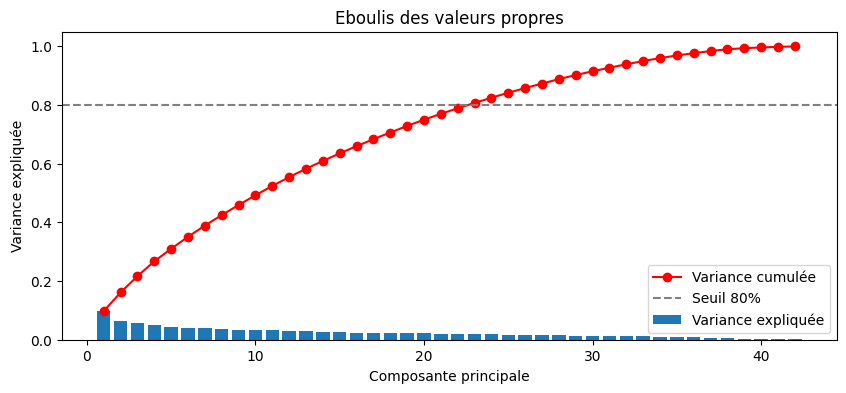

Variance cumulée par composante :
  CP1 : 9.78%
  CP2 : 16.10%
  CP3 : 21.67%
  CP4 : 26.72%
  CP5 : 31.02%
  CP6 : 35.07%
  CP7 : 38.92%
  CP8 : 42.48%
  CP9 : 45.92%
  CP10 : 49.25%
  CP11 : 52.42%
  CP12 : 55.43%
  CP13 : 58.27%
  CP14 : 60.95%
  CP15 : 63.54%
  CP16 : 65.98%
  CP17 : 68.37%
  CP18 : 70.64%
  CP19 : 72.87%
  CP20 : 75.01%
  CP21 : 77.01%
  CP22 : 78.91%
  CP23 : 80.72%
  => 23 composantes suffisent pour 80% de variance
✅ Sauvegardé dans 'variance_expliquee.csv'


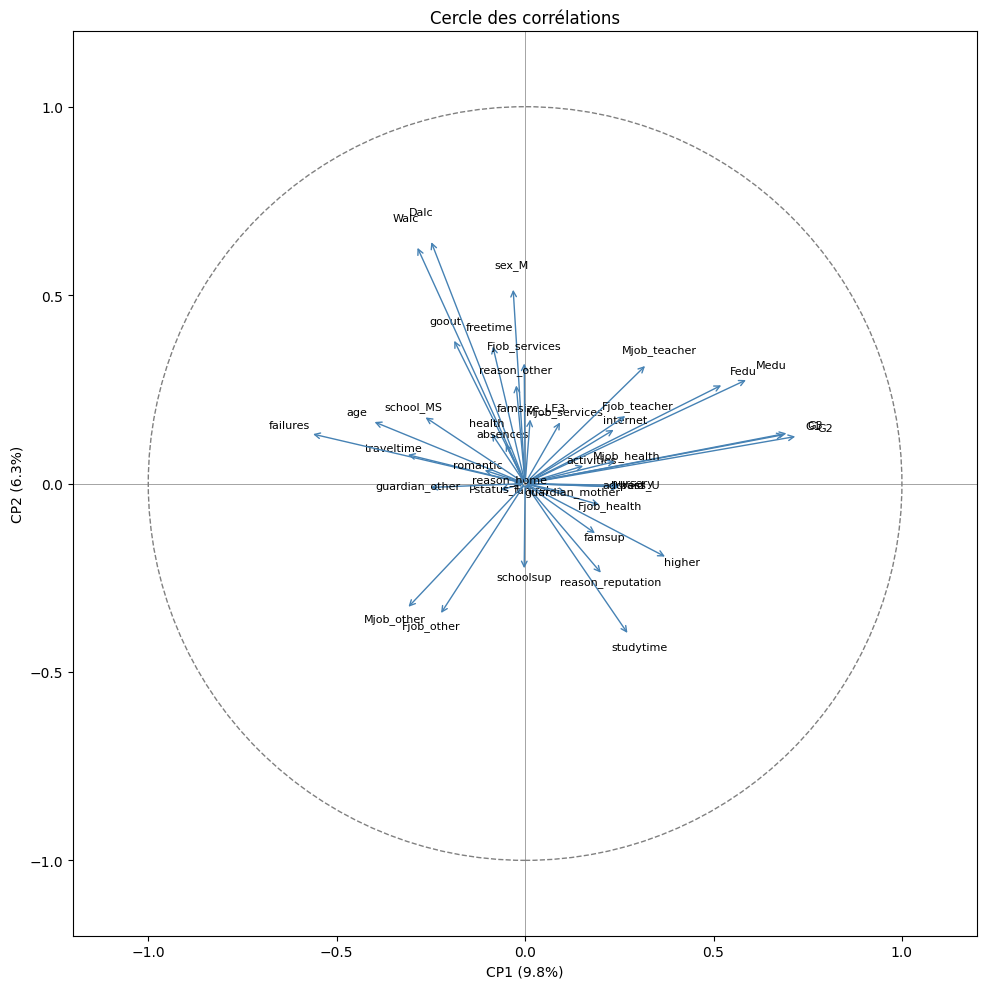

In [14]:
# ---- 1. Séparation numériques / catégorielles ----
num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
            'absences', 'G1', 'G2', 'G3']

cat_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
            'Mjob', 'Fjob', 'reason', 'guardian']

bool_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery',
             'higher', 'internet', 'romantic']

# ---- 2. Encodage one-hot des catégorielles ----
encoder = OneHotEncoder(sparse_output=False, drop='first')
cat_encoded = encoder.fit_transform(student_mat[cat_cols])
cat_encoded_df = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

# Booléens en int (True/False -> 1/0)
bool_df = student_mat[bool_cols].astype(int)

# ---- 3. Assemblage du DataFrame final ----
df_acp = pd.concat([
    student_mat[num_cols].reset_index(drop=True),
    bool_df.reset_index(drop=True),
    cat_encoded_df.reset_index(drop=True)
], axis=1)

# ---- 4. Centrage-réduction ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_acp)

# ---- 5.1 ACP ----
pca = PCA()
pca.fit(X_scaled)

# ---- 5.2 SAVE ----
X_scaled_df = pd.DataFrame(X_scaled, columns=df_acp.columns)
X_scaled_df.to_csv('donnees/X_scaled_mat.csv', index=False)
print("✅ Sauvegardé dans 'donnees/X_scaled_mat.csv'")

# ---- 6. Variance expliquée ----
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.bar(range(1, len(explained)+1), explained, label='Variance expliquée')
plt.plot(range(1, len(explained)+1), cumulative, color='red',
         marker='o', label='Variance cumulée')
plt.axhline(y=0.8, color='gray', linestyle='--', label='Seuil 80%')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée')
plt.title('Eboulis des valeurs propres')
plt.legend()
plt.show()

print("Variance cumulée par composante :")
for i, v in enumerate(cumulative):
    print(f"  CP{i+1} : {v:.2%}")
    if v >= 0.80:
        print(f"  => {i+1} composantes suffisent pour 80% de variance")
        break

variance_df = pd.DataFrame({
    'composante': [f'CP{i+1}' for i in range(len(explained))],
    'variance_expliquee_%': (explained * 100).round(2),
    'variance_cumulee_%': (cumulative * 100).round(2)
})

variance_df.to_csv('variance_expliquee.csv', index=False)
print("✅ Sauvegardé dans 'variance_expliquee.csv'")

# ---- 7. Cercle des corrélations ----
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# Corrélations variables/composantes
correlations = pca_2.components_.T * np.sqrt(pca_2.explained_variance_)

fig, ax = plt.subplots(figsize=(10, 10))

# Flèches
for i, var in enumerate(df_acp.columns):
    ax.annotate("", xy=(correlations[i, 0], correlations[i, 1]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue"))
    ax.text(correlations[i, 0] * 1.1, correlations[i, 1] * 1.1,
            var, fontsize=8, ha='center')

# Cercle
cercle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax.add_patch(cercle)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'CP1 ({pca_2.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'CP2 ({pca_2.explained_variance_ratio_[1]:.1%})')
ax.set_title('Cercle des corrélations')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Deuxième version avec moins de variables

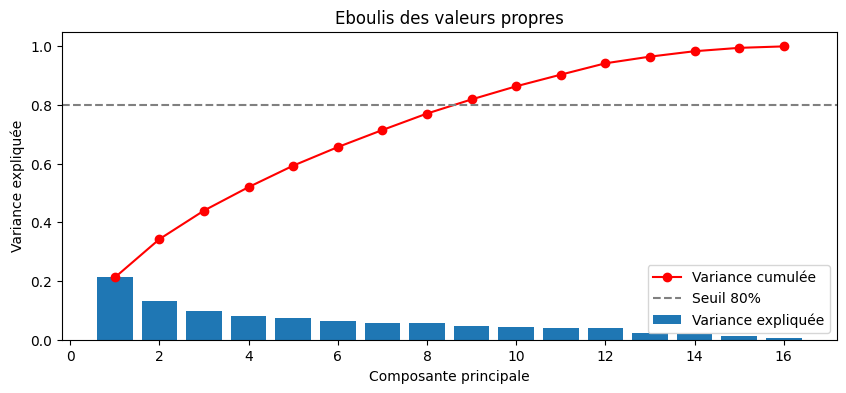

Variance cumulée par composante :
  CP1 : 21.22%
  CP2 : 34.30%
  CP3 : 44.04%
  CP4 : 52.03%
  CP5 : 59.34%
  CP6 : 65.67%
  CP7 : 71.49%
  CP8 : 77.10%
  CP9 : 81.92%
  => 9/16 composantes suffisent pour 80% de variance


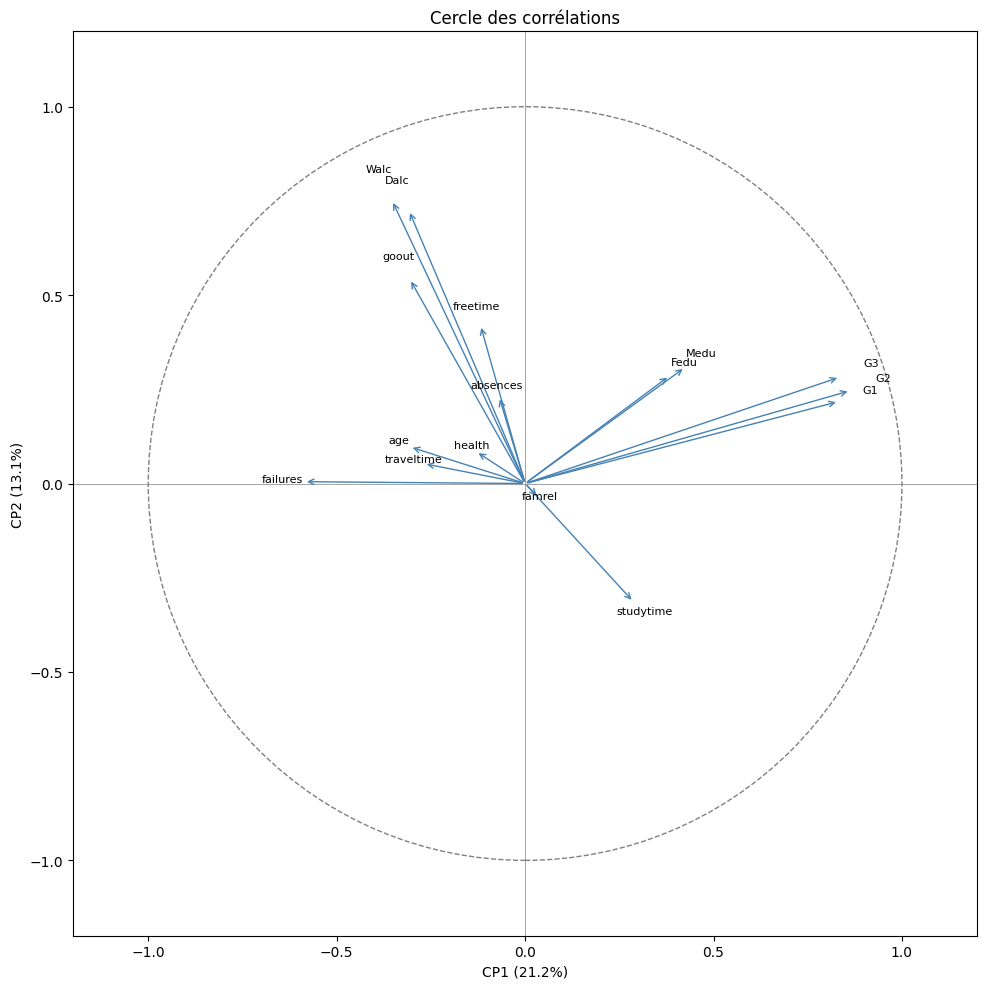

In [15]:
# ---- 1. Séparation numériques / catégorielles ----
num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
            'absences', 'G1', 'G2', 'G3']

cat_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
            'Mjob', 'Fjob', 'reason', 'guardian']

bool_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery',
             'higher', 'internet', 'romantic']

# ---- 2. Encodage one-hot des catégorielles ----
encoder = OneHotEncoder(sparse_output=False, drop='first')
cat_encoded = encoder.fit_transform(student_mat[cat_cols])
cat_encoded_df = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

# Booléens en int (True/False -> 1/0)
bool_df = student_mat[bool_cols].astype(int)

# ---- 3. Assemblage du DataFrame final ----
df_acp = pd.concat([
    student_mat[num_cols].reset_index(drop=True),
], axis=1)

# ---- 4. Centrage-réduction ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_acp)

# ---- 5. ACP ----
pca = PCA()
pca.fit(X_scaled)

# ---- 6. Variance expliquée ----
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.bar(range(1, len(explained)+1), explained, label='Variance expliquée')
plt.plot(range(1, len(explained)+1), cumulative, color='red',
         marker='o', label='Variance cumulée')
plt.axhline(y=0.8, color='gray', linestyle='--', label='Seuil 80%')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée')
plt.title('Eboulis des valeurs propres')
plt.legend()
plt.show()

print("Variance cumulée par composante :")
for i, v in enumerate(cumulative):
    print(f"  CP{i+1} : {v:.2%}")
    if v >= 0.80:
        print(f"  => {i+1}/{len(num_cols)} composantes suffisent pour 80% de variance")
        break

# ---- 7. Cercle des corrélations ----
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# Corrélations variables/composantes
correlations = pca_2.components_.T * np.sqrt(pca_2.explained_variance_)

fig, ax = plt.subplots(figsize=(10, 10))

# Flèches
for i, var in enumerate(df_acp.columns):
    ax.annotate("", xy=(correlations[i, 0], correlations[i, 1]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue"))
    ax.text(correlations[i, 0] * 1.1, correlations[i, 1] * 1.1,
            var, fontsize=8, ha='center')

# Cercle
cercle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax.add_patch(cercle)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'CP1 ({pca_2.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'CP2 ({pca_2.explained_variance_ratio_[1]:.1%})')
ax.set_title('Cercle des corrélations')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

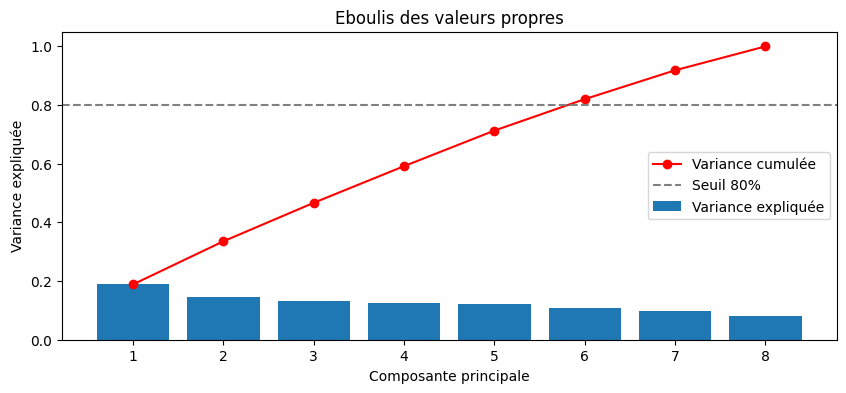

Variance cumulée par composante :
  CP1 : 18.88%
  CP2 : 33.57%
  CP3 : 46.69%
  CP4 : 59.18%
  CP5 : 71.31%
  CP6 : 82.02%
  => 6/8 composantes suffisent pour 80% de variance


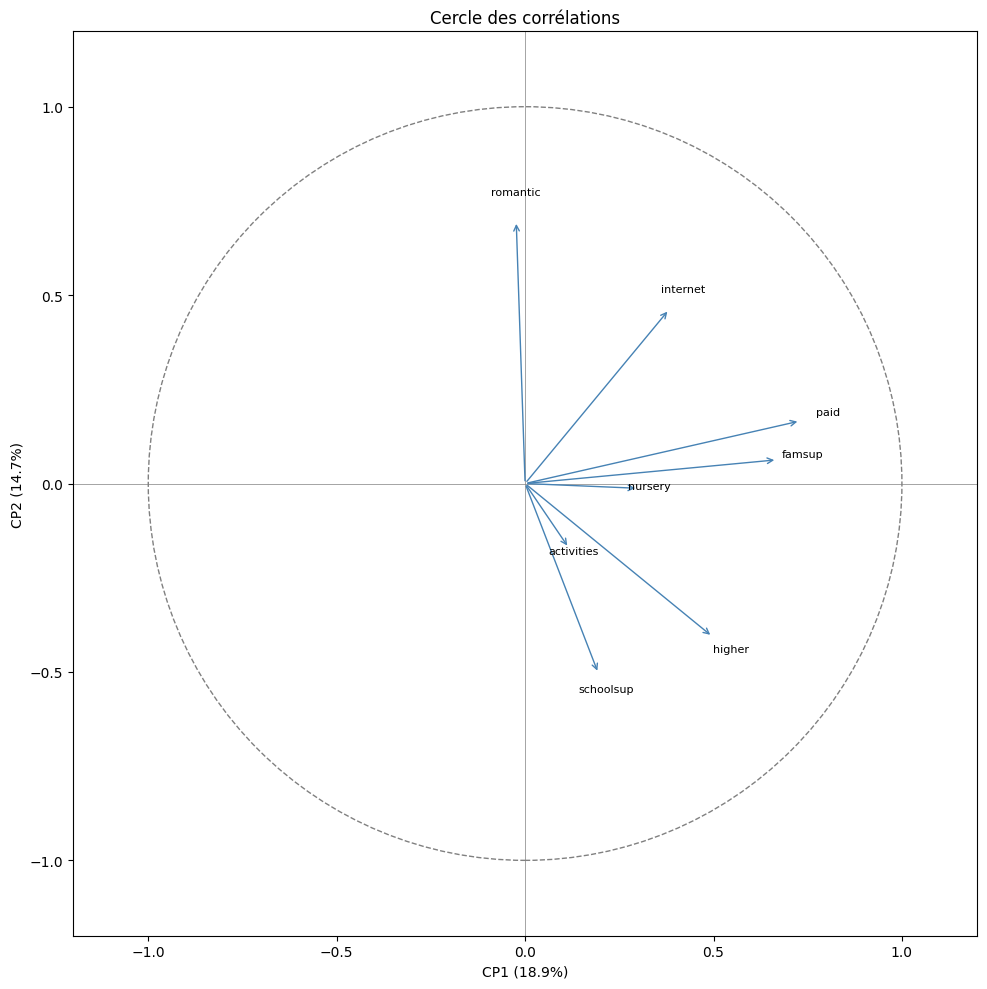

In [16]:
# ---- 1. Séparation numériques / catégorielles ----
num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
            'absences', 'G1', 'G2', 'G3']

cat_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
            'Mjob', 'Fjob', 'reason', 'guardian']

bool_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery',
             'higher', 'internet', 'romantic']

# ---- 2. Encodage one-hot des catégorielles ----
encoder = OneHotEncoder(sparse_output=False, drop='first')
cat_encoded = encoder.fit_transform(student_mat[cat_cols])
cat_encoded_df = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

# Booléens en int (True/False -> 1/0)
bool_df = student_mat[bool_cols].astype(int)

# ---- 3. Assemblage du DataFrame final ----
df_acp = pd.concat([
    bool_df.reset_index(drop=True),
], axis=1)

# ---- 4. Centrage-réduction ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_acp)

# ---- 5. ACP ----
pca = PCA()
pca.fit(X_scaled)

# ---- 6. Variance expliquée ----
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.bar(range(1, len(explained)+1), explained, label='Variance expliquée')
plt.plot(range(1, len(explained)+1), cumulative, color='red',
         marker='o', label='Variance cumulée')
plt.axhline(y=0.8, color='gray', linestyle='--', label='Seuil 80%')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée')
plt.title('Eboulis des valeurs propres')
plt.legend()
plt.show()

print("Variance cumulée par composante :")
for i, v in enumerate(cumulative):
    print(f"  CP{i+1} : {v:.2%}")
    if v >= 0.80:
        print(f"  => {i+1}/{len(bool_cols)} composantes suffisent pour 80% de variance")
        break

# ---- 7. Cercle des corrélations ----
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# Corrélations variables/composantes
correlations = pca_2.components_.T * np.sqrt(pca_2.explained_variance_)

fig, ax = plt.subplots(figsize=(10, 10))

# Flèches
for i, var in enumerate(df_acp.columns):
    ax.annotate("", xy=(correlations[i, 0], correlations[i, 1]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue"))
    ax.text(correlations[i, 0] * 1.1, correlations[i, 1] * 1.1,
            var, fontsize=8, ha='center')

# Cercle
cercle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax.add_patch(cercle)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'CP1 ({pca_2.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'CP2 ({pca_2.explained_variance_ratio_[1]:.1%})')
ax.set_title('Cercle des corrélations')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

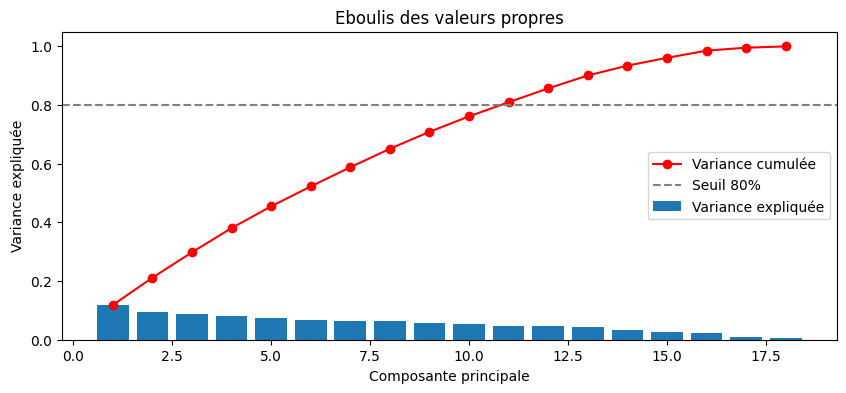

Variance cumulée par composante :
  CP1 : 11.82%
  CP2 : 21.15%
  CP3 : 29.81%
  CP4 : 38.07%
  CP5 : 45.47%
  CP6 : 52.26%
  CP7 : 58.80%
  CP8 : 65.11%
  CP9 : 70.87%
  CP10 : 76.14%
  CP11 : 80.97%
  => 11/9 composantes suffisent pour 80% de variance


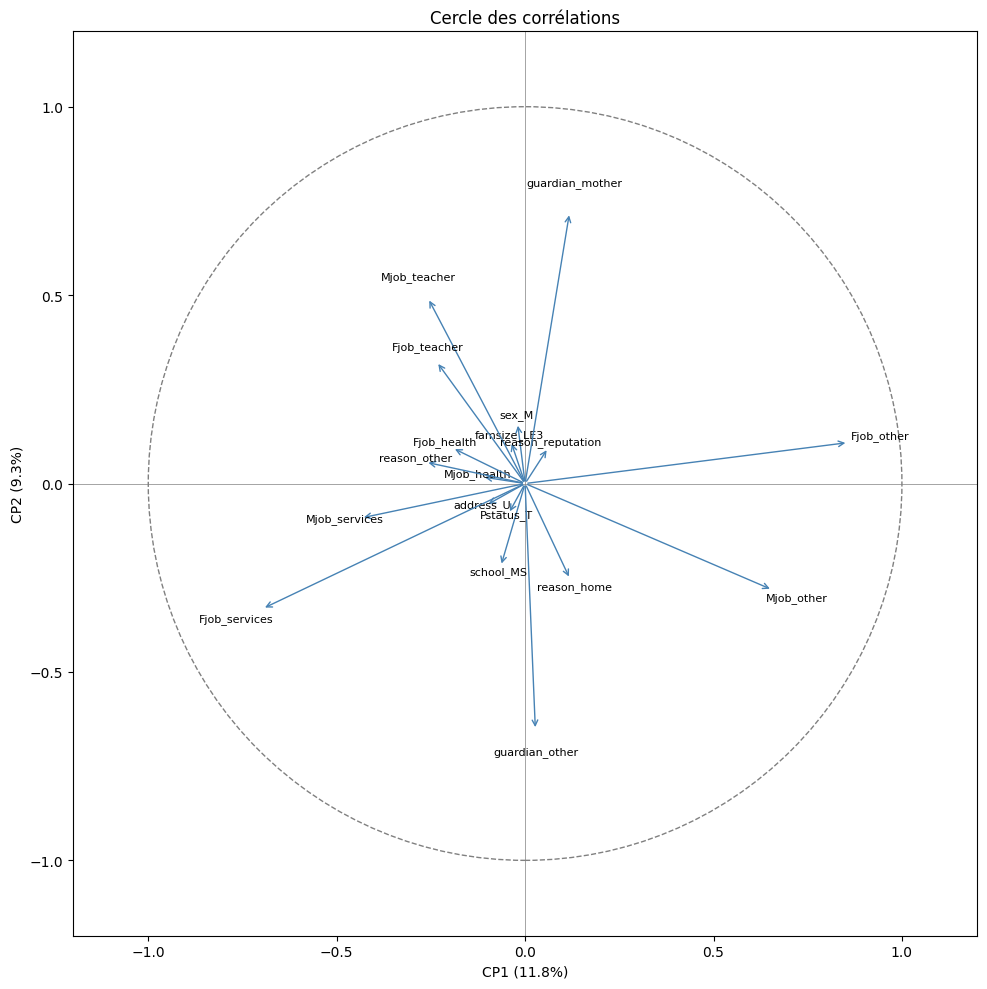

In [17]:
# ---- 1. Séparation numériques / catégorielles ----
num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
            'absences', 'G1', 'G2', 'G3']

cat_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
            'Mjob', 'Fjob', 'reason', 'guardian']

bool_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery',
             'higher', 'internet', 'romantic']

# ---- 2. Encodage one-hot des catégorielles ----
encoder = OneHotEncoder(sparse_output=False, drop='first')
cat_encoded = encoder.fit_transform(student_mat[cat_cols])
cat_encoded_df = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

# Booléens en int (True/False -> 1/0)
bool_df = student_mat[bool_cols].astype(int)

# ---- 3. Assemblage du DataFrame final ----
df_acp = pd.concat([
    cat_encoded_df.reset_index(drop=True)
], axis=1)

# ---- 4. Centrage-réduction ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_acp)

# ---- 5. ACP ----
pca = PCA()
pca.fit(X_scaled)

# ---- 6. Variance expliquée ----
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.bar(range(1, len(explained)+1), explained, label='Variance expliquée')
plt.plot(range(1, len(explained)+1), cumulative, color='red',
         marker='o', label='Variance cumulée')
plt.axhline(y=0.8, color='gray', linestyle='--', label='Seuil 80%')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée')
plt.title('Eboulis des valeurs propres')
plt.legend()
plt.show()

print("Variance cumulée par composante :")
for i, v in enumerate(cumulative):
    print(f"  CP{i+1} : {v:.2%}")
    if v >= 0.80:
        print(f"  => {i+1}/{len(cat_cols)} composantes suffisent pour 80% de variance")
        break

# ---- 7. Cercle des corrélations ----
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# Corrélations variables/composantes
correlations = pca_2.components_.T * np.sqrt(pca_2.explained_variance_)

fig, ax = plt.subplots(figsize=(10, 10))

# Flèches
for i, var in enumerate(df_acp.columns):
    ax.annotate("", xy=(correlations[i, 0], correlations[i, 1]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue"))
    ax.text(correlations[i, 0] * 1.1, correlations[i, 1] * 1.1,
            var, fontsize=8, ha='center')

# Cercle
cercle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax.add_patch(cercle)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'CP1 ({pca_2.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'CP2 ({pca_2.explained_variance_ratio_[1]:.1%})')
ax.set_title('Cercle des corrélations')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Pairplot

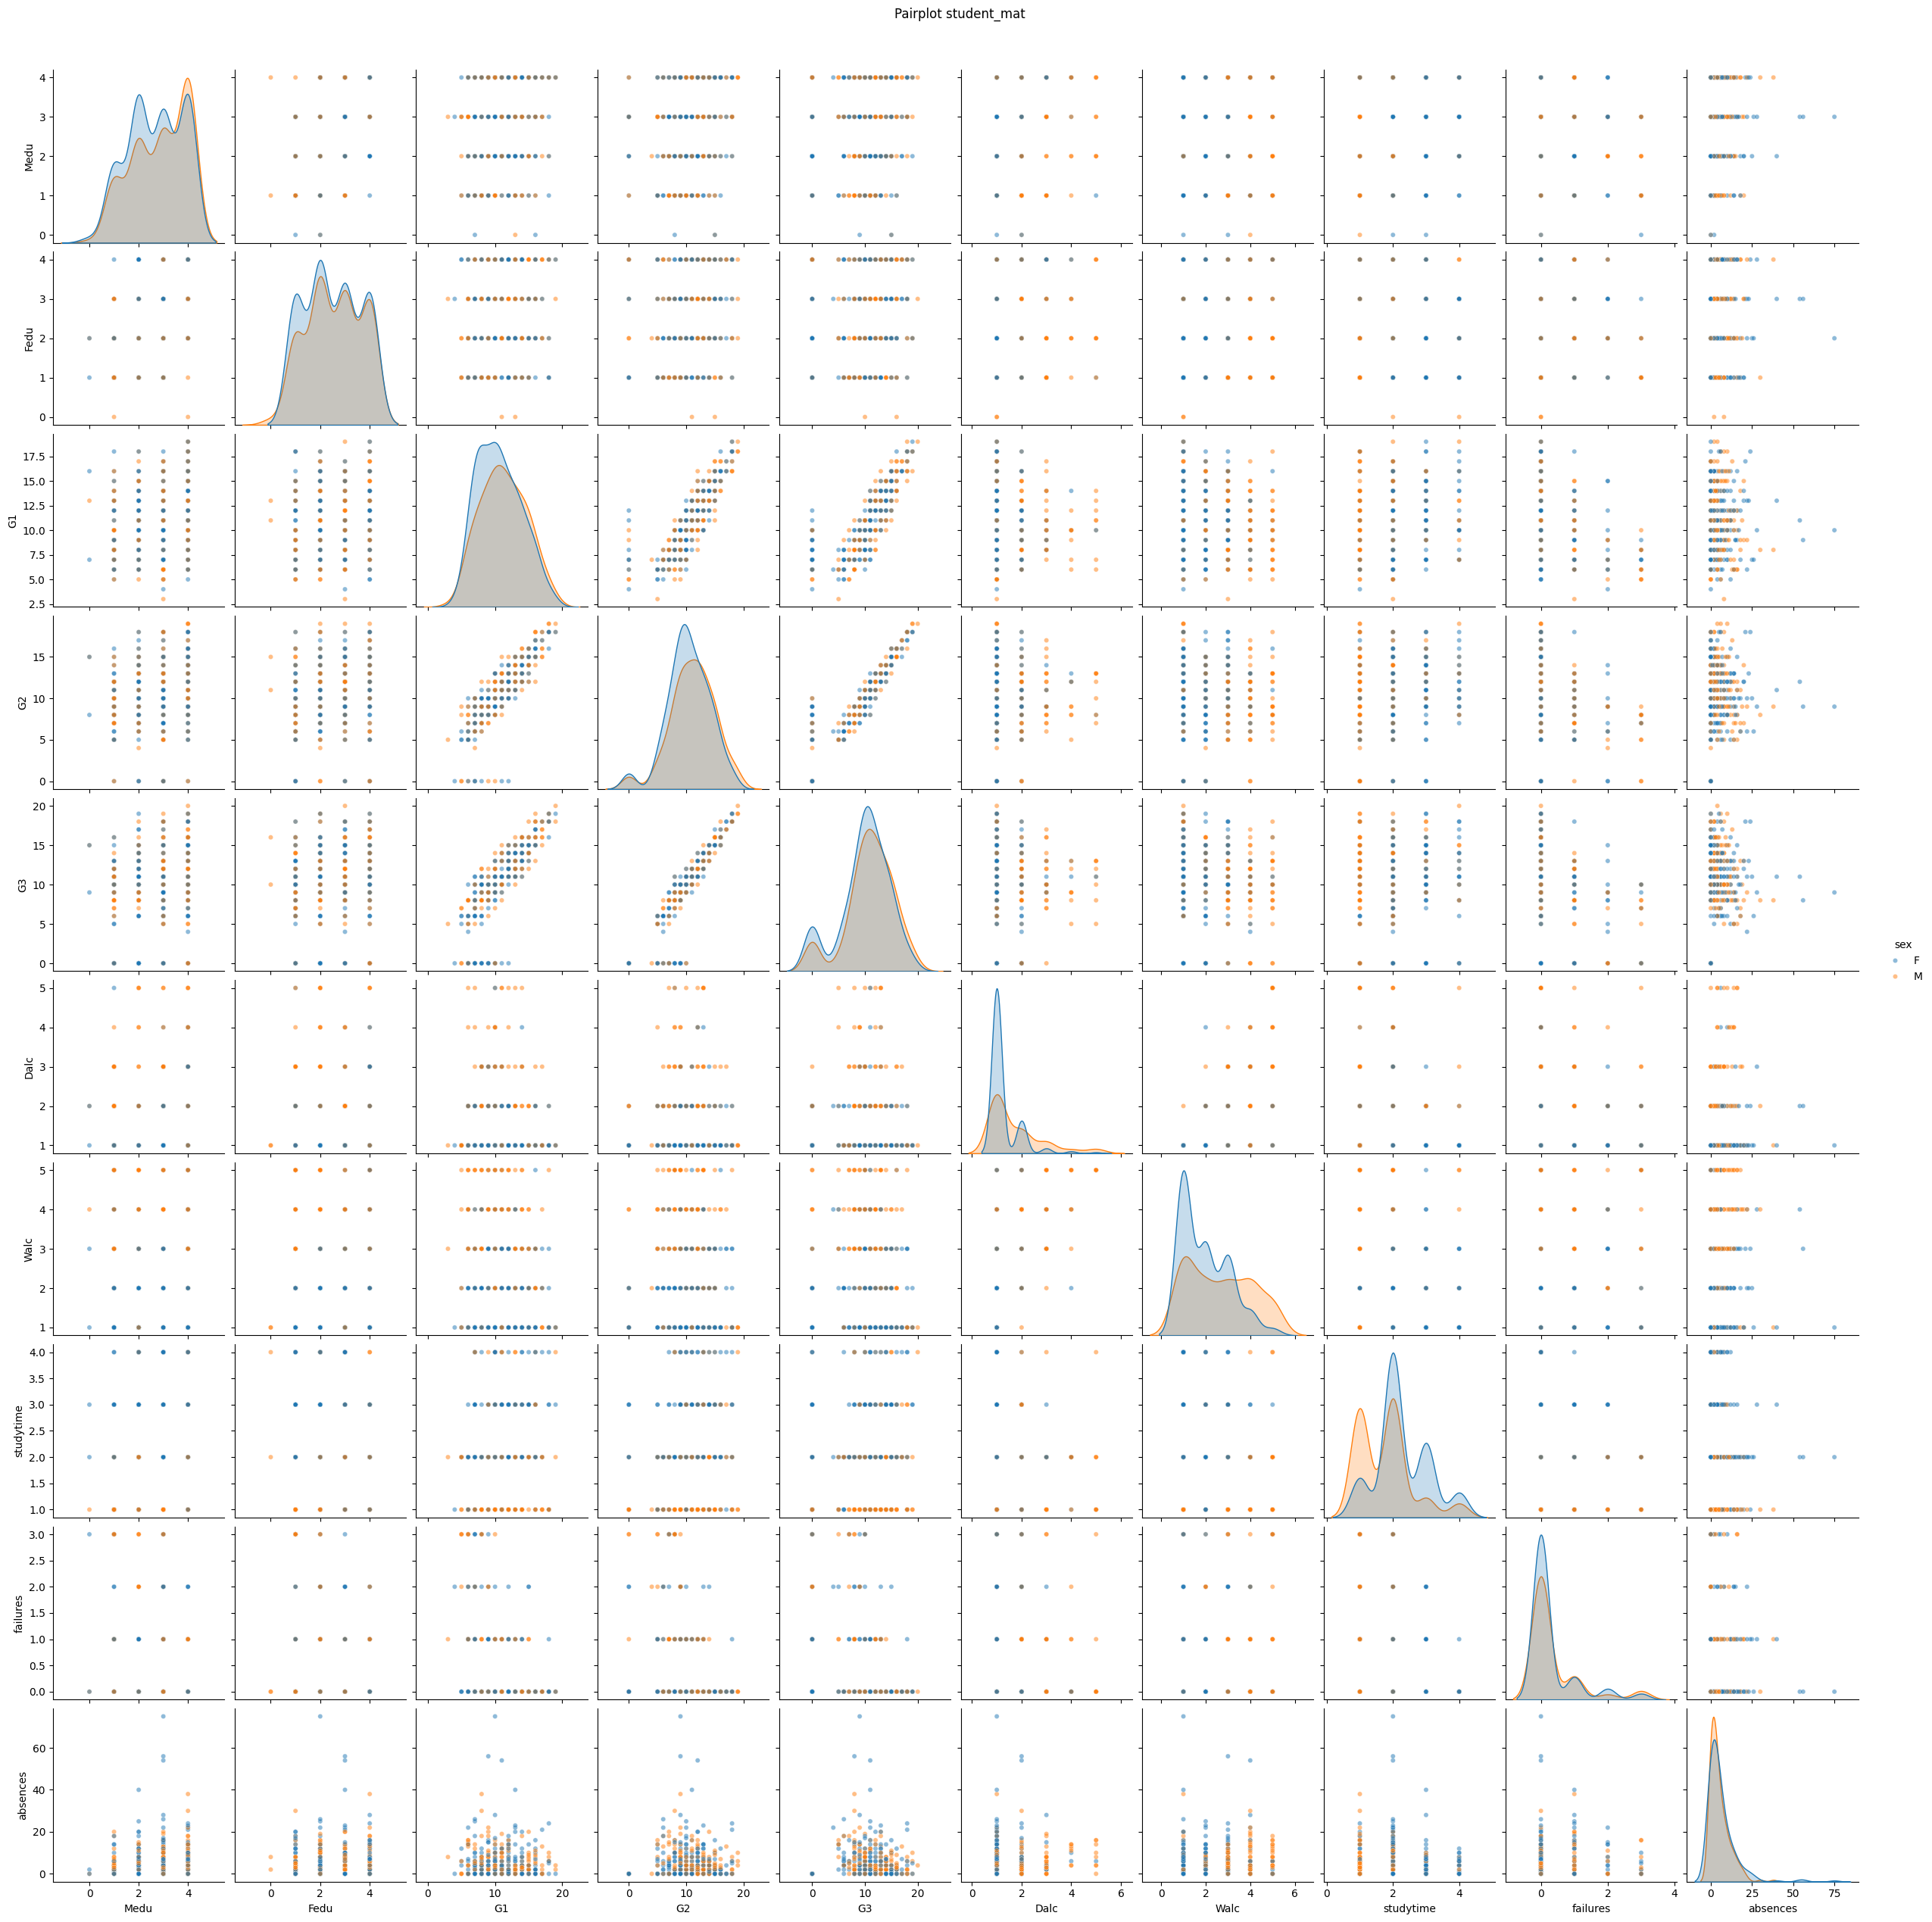

In [18]:
# ---- Pairplot ----
cols_pairplot = ['Medu', 'Fedu', 'G1', 'G2', 'G3', 
                 'Dalc', 'Walc', 'studytime', 'failures', 'absences']

sns.pairplot(
    student_mat[cols_pairplot + ['sex']],
    hue='sex',
    plot_kws={'alpha': 0.5, 's': 20},
    diag_kind='kde'
)
plt.suptitle('Pairplot student_mat', y=1.02)
plt.show()

# Corrélation

In [19]:
cols_corr = ['Medu', 'Fedu', 'G1', 'G2', 'G3', 
             'Dalc', 'Walc', 'studytime', 'failures', 
             'absences', 'traveltime', 'goout', 'freetime']

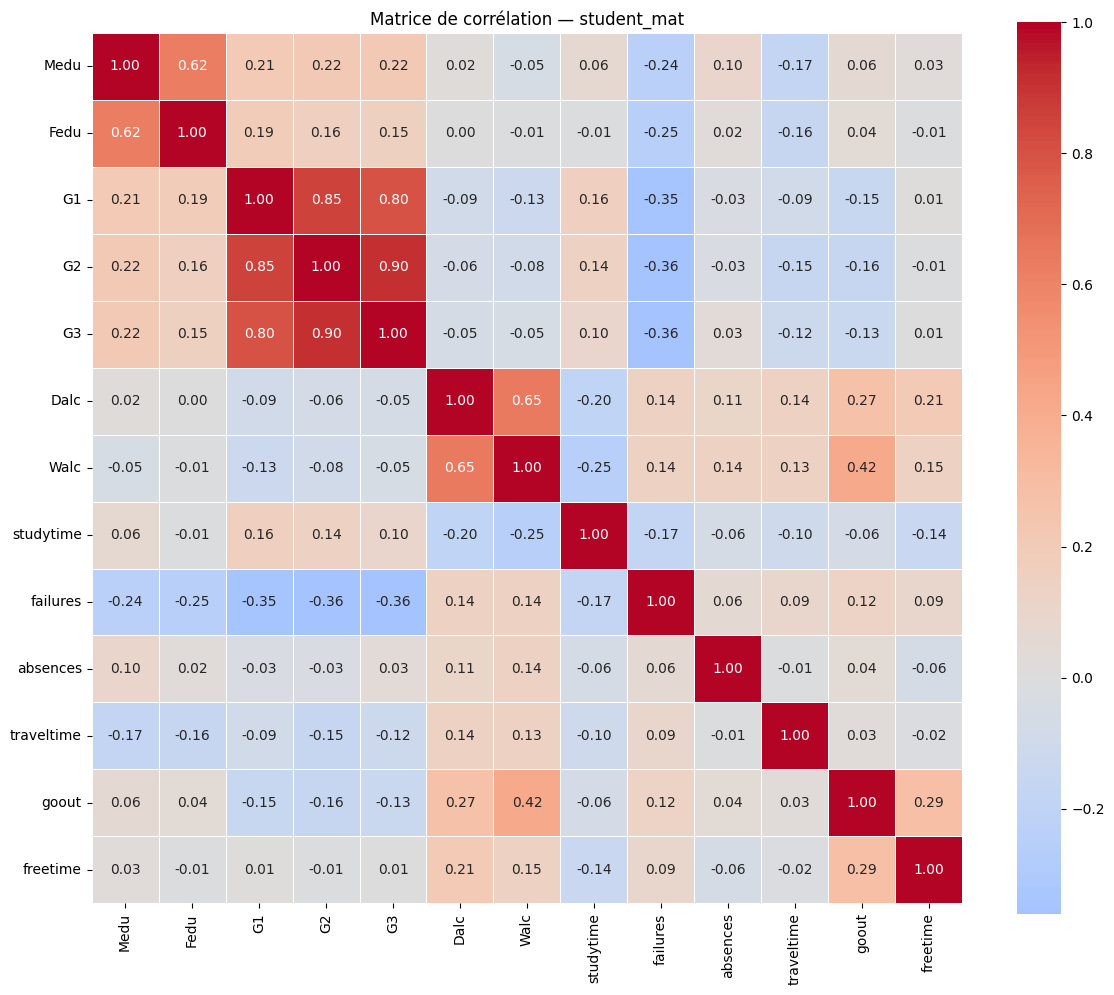

In [20]:
corr_matrix = student_mat[cols_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Matrice de corrélation — student_mat')
plt.tight_layout()
plt.show()

# Box plots G3 vs Medu et Fedu

L'objectif ici est de voir l'influence de l'éducation des parents sur les résultat de l'élève (en fonction du sexe également)

/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_40996/3873001195.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='G3', data=student_mat, ax=ax, palette='coolwarm')
/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_40996/3873001195.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='G3', data=student_mat, ax=ax, palette='coolwarm')


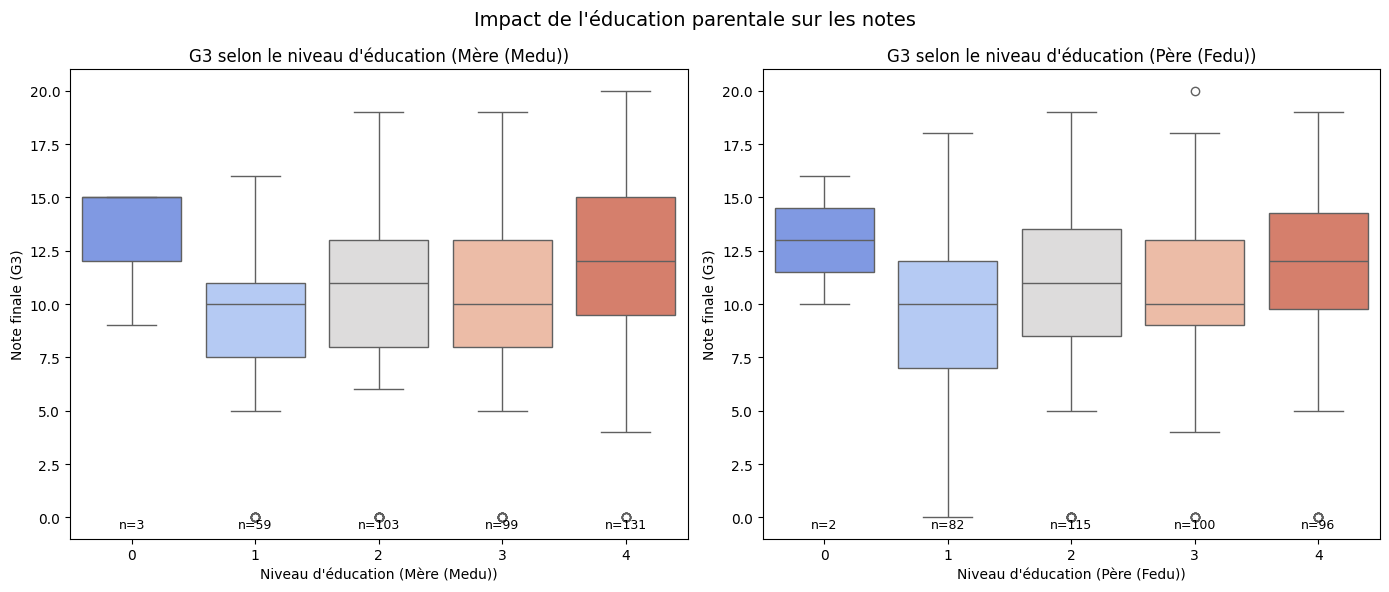

In [21]:
# ---- Boxplots G3 vs Medu et Fedu avec effectifs ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, label in zip(axes, ['Medu', 'Fedu'], ['Mère (Medu)', 'Père (Fedu)']):
    sns.boxplot(x=col, y='G3', data=student_mat, ax=ax, palette='coolwarm')
    
    # Ajout des effectifs
    counts = student_mat[col].value_counts().sort_index()
    for i, (level, count) in enumerate(counts.items()):
        ax.text(i, ax.get_ylim()[0] + 0.5, f'n={count}', 
                ha='center', fontsize=9, color='black')
    
    ax.set_title(f'G3 selon le niveau d\'éducation ({label})')
    ax.set_xlabel(f'Niveau d\'éducation ({label})')
    ax.set_ylabel('Note finale (G3)')

plt.suptitle('Impact de l\'éducation parentale sur les notes', fontsize=14)
plt.tight_layout()
plt.show()

On remarque que les effectifs Fedu = 0 et Medu = 0 sont très faible donc on retire

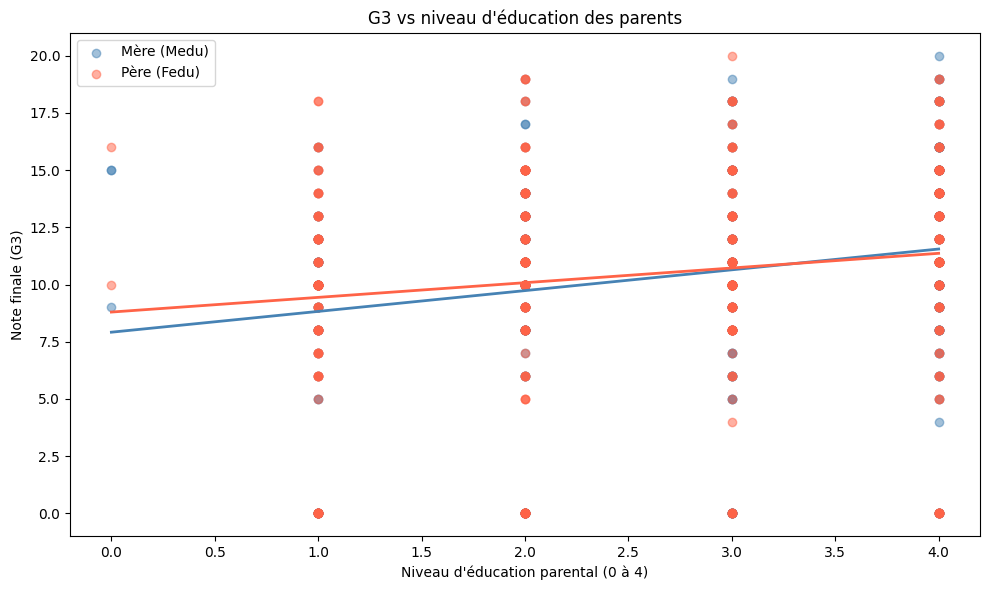

In [22]:
# ---- Scatterplot G3 vs Medu et Fedu ----
plt.figure(figsize=(10, 6))

plt.scatter(student_mat['Medu'], student_mat['G3'], 
            alpha=0.5, color='steelblue', label='Mère (Medu)')
plt.scatter(student_mat['Fedu'], student_mat['G3'], 
            alpha=0.5, color='tomato', label='Père (Fedu)')

# Droites de tendance
for col, color in [('Medu', 'steelblue'), ('Fedu', 'tomato')]:
    z = np.polyfit(student_mat[col], student_mat['G3'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(student_mat[col].min(), student_mat[col].max(), 100)
    plt.plot(x_line, p(x_line), color=color, linewidth=2)

plt.xlabel('Niveau d\'éducation parental (0 à 4)')
plt.ylabel('Note finale (G3)')
plt.title('G3 vs niveau d\'éducation des parents')
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_40996/2061016454.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='G3', data=data_sex, ax=ax, palette='coolwarm')
/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_40996/2061016454.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='G3', data=data_sex, ax=ax, palette='coolwarm')
/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_40996/2061016454.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='G3', data=data_sex, ax=ax, palette='

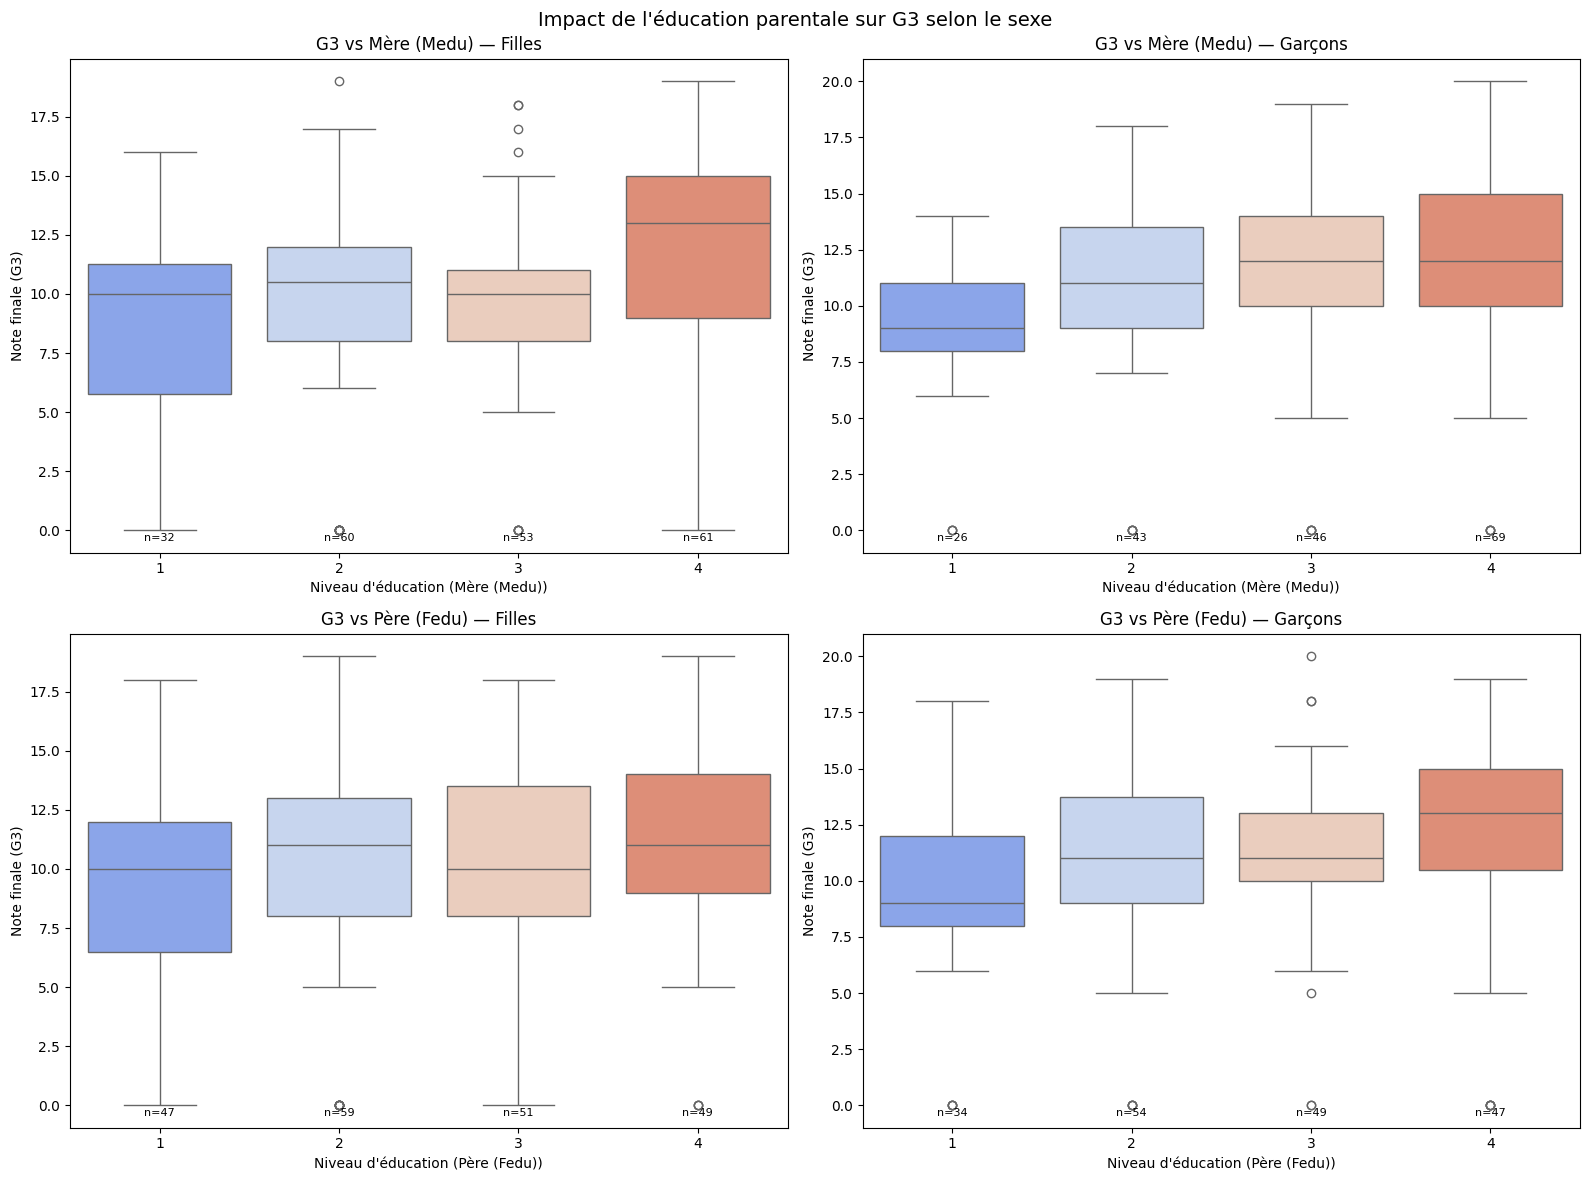


G3 selon Mère (Medu) et sexe
           n  moyenne  médiane     Q1     Q3  écart-type
Medu sex                                                
1    F    32     8.56     10.0   5.75  11.25        4.77
     M    26     8.54      9.0   8.00  11.00        3.71
2    F    60     9.22     10.5   8.00  12.00        4.88
     M    43    10.44     11.0   9.00  13.50        4.23
3    F    53     9.64     10.0   8.00  11.00        4.40
     M    46    11.07     12.0  10.00  14.00        4.80
4    F    61    11.66     13.0   9.00  15.00        4.09
     M    69    11.88     12.0  10.00  15.00        4.47

G3 selon Père (Fedu) et sexe
           n  moyenne  médiane    Q1     Q3  écart-type
Fedu sex                                               
1    F    47     9.04     10.0   6.5  12.00        4.66
     M    34     9.32      9.0   8.0  12.00        4.56
2    F    59     9.64     11.0   8.0  13.00        5.05
     M    54    10.76     11.0   9.0  13.75        4.33
3    F    51    10.25     10.0   8

In [23]:
# Dataset sans les Fedu et Medu à 0
student_mat_clean = student_mat[(student_mat["Medu"] != 0) & (student_mat["Fedu"] != 0)]


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for col, label, row in zip(['Medu', 'Fedu'], ['Mère (Medu)', 'Père (Fedu)'], [0, 1]):
    for sex, col_idx in zip(['F', 'M'], [0, 1]):
        ax = axes[row][col_idx]
        data_sex = student_mat_clean[student_mat_clean['sex'] == sex]
        
        sns.boxplot(x=col, y='G3', data=data_sex, ax=ax, palette='coolwarm')
        
        # Effectifs
        counts = data_sex[col].value_counts().sort_index()
        for i, (level, count) in enumerate(counts.items()):
            ax.text(i, ax.get_ylim()[0] + 0.5, f'n={count}',
                    ha='center', fontsize=8, color='black')
        
        ax.set_title(f'G3 vs {label} — {"Filles" if sex == "F" else "Garçons"}')
        ax.set_xlabel(f'Niveau d\'éducation ({label})')
        ax.set_ylabel('Note finale (G3)')

plt.suptitle('Impact de l\'éducation parentale sur G3 selon le sexe', fontsize=14)
plt.tight_layout()
plt.show()

# ---- Stats descriptives par groupe ----
for col, label in zip(['Medu', 'Fedu'], ['Mère (Medu)', 'Père (Fedu)']):
    print(f"\n{'='*50}")
    print(f"G3 selon {label} et sexe")
    print(f"{'='*50}")
    
    stats = student_mat_clean.groupby([col, 'sex'])['G3'].agg([
        'count', 'mean', 'median', 
        lambda x: x.quantile(0.25),
        lambda x: x.quantile(0.75),
        'std'
    ]).round(2)
    
    stats.columns = ['n', 'moyenne', 'médiane', 'Q1', 'Q3', 'écart-type']
    print(stats.to_string())


**Éducation de la mère (Medu)**

- La progression de niveau 1 → 4 est de **+3.1 points** pour les filles et **+3.3 points** pour les garçons
- Au niveau 4, les deux sexes convergent (~11.7 vs 11.9)

**Éducation du père (Fedu)**

- La progression de niveau 1 → 4 est de seulement **+1.8 points** pour les filles et **+2.6 points** pour les garçons
- L'effet du père est **plus faible** que celui de la mère pour les deux sexes


**Conclusion chiffrée**
- La mère a un effet plus fort (+3 pts) que le père (+2 pts environ) sur G3
- Les garçons ont systématiquement de meilleures moyennes que les filles aux niveaux intermédiaires (2 et 3), mais convergent au niveau 4
- L'écart-type reste élevé partout (~4) → beaucoup de variabilité résiduelle

/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_40996/3702789947.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='G3', data=data_g, ax=ax, palette='coolwarm')
/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_40996/3702789947.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='G3', data=data_g, ax=ax, palette='coolwarm')
/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_40996/3702789947.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='G3', data=data_g, ax=ax, palette='coo

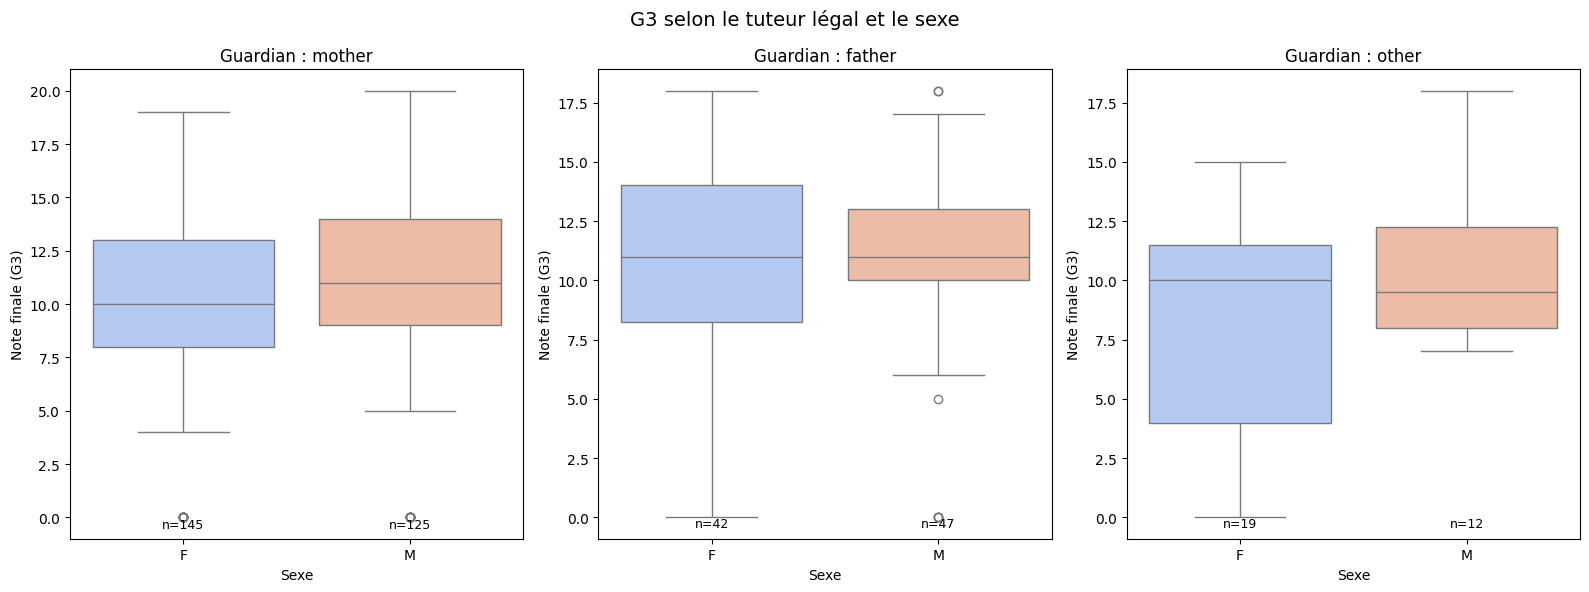

In [24]:
# ---- Boxplots G3 vs guardian avec Medu/Fedu et sex ----
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, guardian in zip(axes, ['mother', 'father', 'other']):
    data_g = student_mat_clean[student_mat_clean['guardian'] == guardian]
    
    sns.boxplot(x='sex', y='G3', data=data_g, ax=ax, palette='coolwarm')
    
    # Effectifs
    counts = data_g['sex'].value_counts()
    for i, sex in enumerate(['F', 'M']):
        n = counts.get(sex, 0)
        ax.text(i, ax.get_ylim()[0] + 0.5, f'n={n}',
                ha='center', fontsize=9)
    
    ax.set_title(f'Guardian : {guardian}')
    ax.set_xlabel('Sexe')
    ax.set_ylabel('Note finale (G3)')

plt.suptitle('G3 selon le tuteur légal et le sexe', fontsize=14)
plt.tight_layout()
plt.show()

Impact du status des parents, l'adresse et le travel time 

/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_40996/31883280.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='address', y='G3', data=student_mat_clean,
/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_40996/31883280.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pstatus', y='G3', data=student_mat_clean,
/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_40996/31883280.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='traveltime', y='G3', data=student_mat_clean,


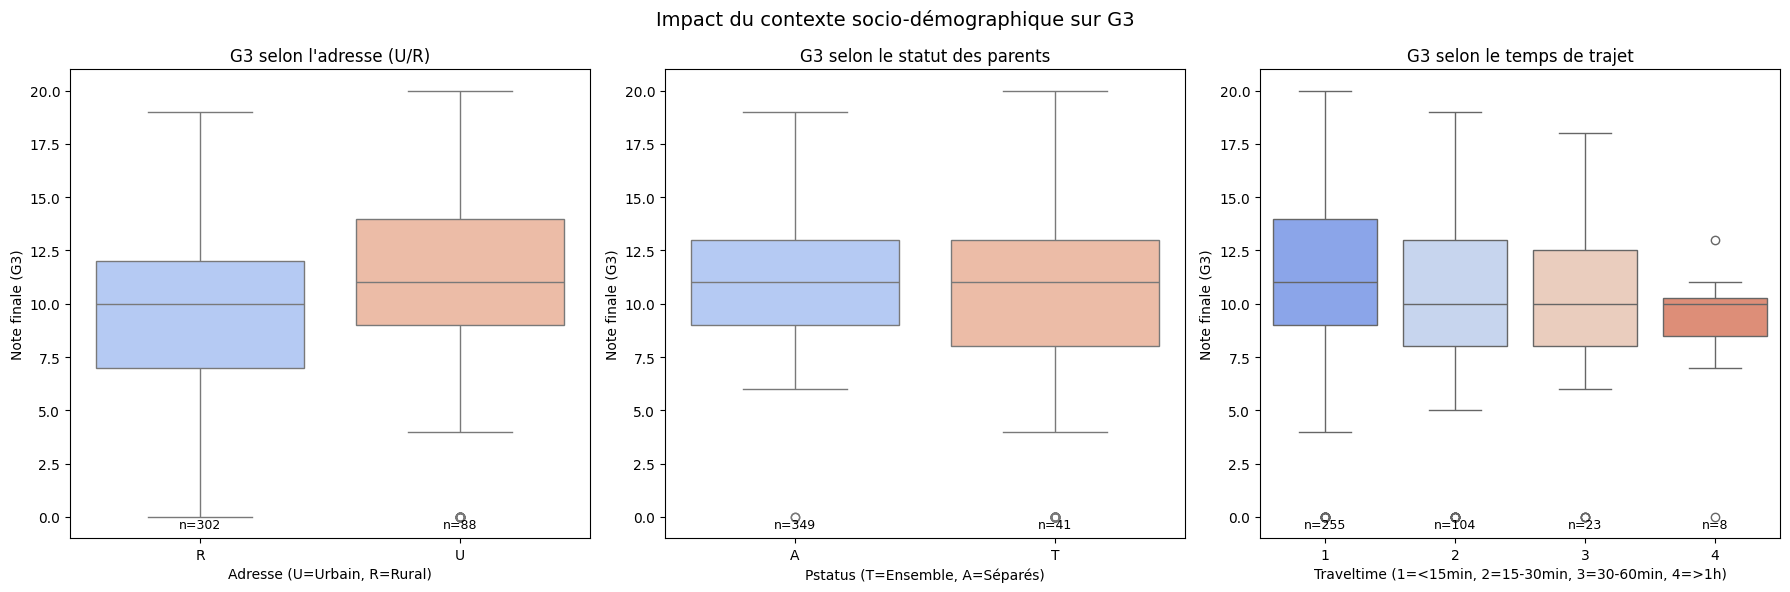

In [25]:
# ---- Boxplots G3 vs address, Pstatus, traveltime ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Address
sns.boxplot(x='address', y='G3', data=student_mat_clean, 
            ax=axes[0], palette='coolwarm')
counts = student_mat_clean['address'].value_counts()
for i, addr in enumerate(['U', 'R']):
    axes[0].text(i, axes[0].get_ylim()[0] + 0.5, f'n={counts.get(addr, 0)}',
                ha='center', fontsize=9)
axes[0].set_title('G3 selon l\'adresse (U/R)')
axes[0].set_xlabel('Adresse (U=Urbain, R=Rural)')
axes[0].set_ylabel('Note finale (G3)')

# Pstatus
sns.boxplot(x='Pstatus', y='G3', data=student_mat_clean,
            ax=axes[1], palette='coolwarm')
counts = student_mat_clean['Pstatus'].value_counts()
for i, ps in enumerate(['T', 'A']):
    axes[1].text(i, axes[1].get_ylim()[0] + 0.5, f'n={counts.get(ps, 0)}',
                ha='center', fontsize=9)
axes[1].set_title('G3 selon le statut des parents')
axes[1].set_xlabel('Pstatus (T=Ensemble, A=Séparés)')
axes[1].set_ylabel('Note finale (G3)')

# Traveltime
sns.boxplot(x='traveltime', y='G3', data=student_mat_clean,
            ax=axes[2], palette='coolwarm')
counts = student_mat_clean['traveltime'].value_counts().sort_index()
for i, (level, count) in enumerate(counts.items()):
    axes[2].text(i, axes[2].get_ylim()[0] + 0.5, f'n={count}',
                ha='center', fontsize=9)
axes[2].set_title('G3 selon le temps de trajet')
axes[2].set_xlabel('Traveltime (1=<15min, 2=15-30min, 3=30-60min, 4=>1h)')
axes[2].set_ylabel('Note finale (G3)')

plt.suptitle('Impact du contexte socio-démographique sur G3', fontsize=14)
plt.tight_layout()
plt.show()

**Address (Urbain/Rural)**
- Urbain (n=302) : médiane ~11, boîte plus haute
- Rural (n=88) : médiane ~10, boîte plus basse et plus resserrée
- Léger avantage urbain, mais pas énorme — probablement lié au fait que les parents urbains sont en moyenne plus éduqués (ce qu'on avait vu avec traveltime/Medu dans la heatmap)

---

**Pstatus (Ensemble/Séparés)**
- Quasiment **aucune différence** entre parents ensemble (T, n=349) et séparés (A, n=41)
- Les boîtes sont presque identiques, médiane ~11 dans les deux cas
- Le statut des parents ne semble pas impacter les notes — résultat contre-intuitif mais intéressant à mentionner

---

**Traveltime**
- Tendance claire : plus le trajet est long, plus les notes baissent
- Niveau 1 (<15min, n=255) : médiane ~11, boîte haute
- Niveau 4 (>1h, n=8) : médiane ~10, boîte très resserrée
- Attention : effectifs très faibles pour niveaux 3 (n=23) et 4 (n=8) → à interpréter avec prudence

---

**Conclusion**
L'adresse et le traveltime ont un effet modéré mais cohérent. Le Pstatus est surprenamment neutre. 


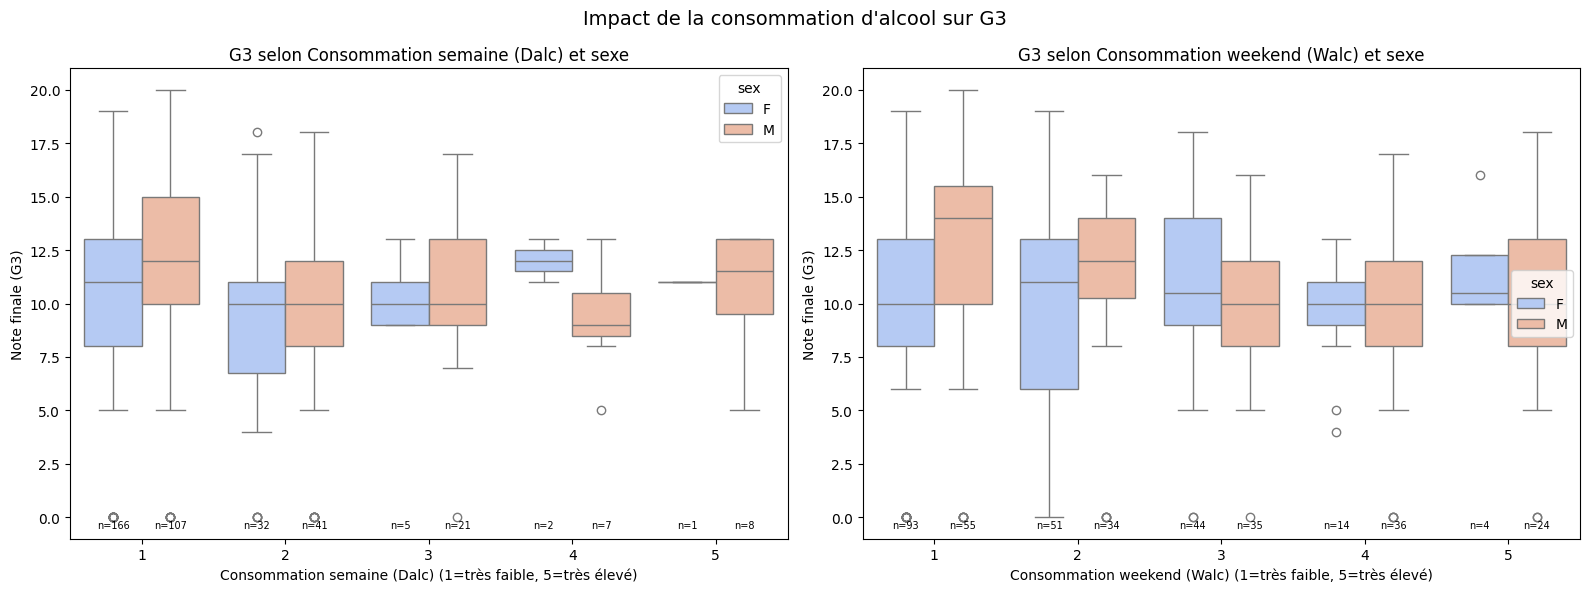

In [26]:
# ---- Boxplots G3 vs Dalc et Walc ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, label in zip(axes, ['Dalc', 'Walc'], 
                           ['Consommation semaine (Dalc)', 'Consommation weekend (Walc)']):
    sns.boxplot(x=col, y='G3', hue='sex', data=student_mat_clean, 
                ax=ax, palette='coolwarm')
    
    # Effectifs
    counts = student_mat_clean.groupby([col, 'sex']).size()
    levels = sorted(student_mat_clean[col].unique())
    for i, level in enumerate(levels):
        for j, sex in enumerate(['F', 'M']):
            n = counts.get((level, sex), 0)
            offset = -0.2 if sex == 'F' else 0.2
            ax.text(i + offset, ax.get_ylim()[0] + 0.5, f'n={n}',
                   ha='center', fontsize=7)
    
    ax.set_title(f'G3 selon {label} et sexe')
    ax.set_xlabel(f'{label} (1=très faible, 5=très élevé)')
    ax.set_ylabel('Note finale (G3)')

plt.suptitle('Impact de la consommation d\'alcool sur G3', fontsize=14)
plt.tight_layout()
plt.show()


**Impact sur G3**

- L'effet de l'alcool sur les notes est **peu visible** — les médianes restent stables entre niveaux
- Pas de chute claire de G3 avec l'augmentation de la consommation
- Confirme ce qu'on voyait dans la heatmap : corrélation faible entre alcool et notes

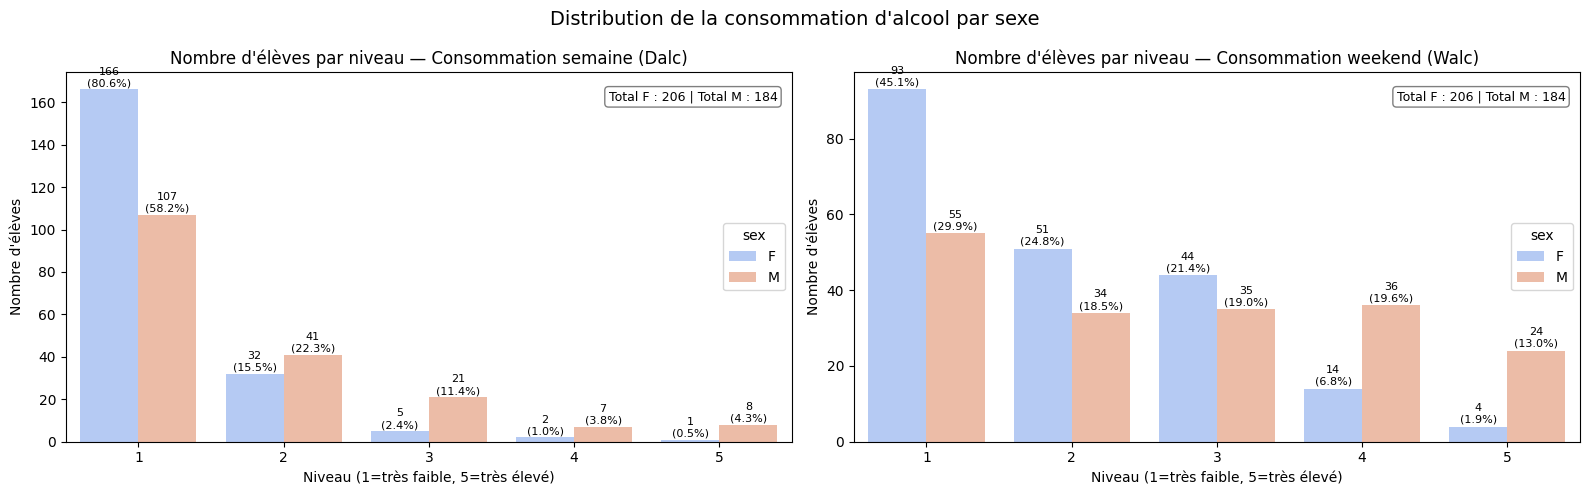

In [27]:
# ---- Distribution des consommateurs par niveau et sexe ----
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

total_F = len(student_mat_clean[student_mat_clean['sex'] == 'F'])
total_M = len(student_mat_clean[student_mat_clean['sex'] == 'M'])

for ax, col, label in zip(axes, ['Dalc', 'Walc'],
                           ['Consommation semaine (Dalc)', 'Consommation weekend (Walc)']):
    counts = student_mat_clean.groupby([col, 'sex']).size().reset_index(name='n')
    counts['pct'] = counts.apply(
        lambda r: r['n'] / total_F * 100 if r['sex'] == 'F' else r['n'] / total_M * 100, axis=1
    ).round(1)
    
    sns.barplot(x=col, y='n', hue='sex', data=counts, ax=ax, palette='coolwarm')
    
    levels = sorted(student_mat_clean[col].unique())
    for i, level in enumerate(levels):
        for j, sex in enumerate(['F', 'M']):
            row = counts[(counts[col] == level) & (counts['sex'] == sex)]
            if len(row) == 0:
                continue
            n = int(row['n'].values[0])
            pct = row['pct'].values[0]
            # offset selon F ou M
            x = i - 0.2 if sex == 'F' else i + 0.2
            ax.text(x, n + 0.5, f'{n}\n({pct}%)',
                   ha='center', va='bottom', fontsize=8)
    
    ax.set_title(f'Nombre d\'élèves par niveau — {label}')
    ax.set_xlabel(f'Niveau (1=très faible, 5=très élevé)')
    ax.set_ylabel('Nombre d\'élèves')
    ax.text(0.98, 0.95, f'Total F : {total_F} | Total M : {total_M}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.suptitle('Distribution de la consommation d\'alcool par sexe', fontsize=14)
plt.tight_layout()
plt.show()

**Distribution de la consommation (barplots)**

Dalc (semaine) :
- **80.6% des filles** sont au niveau 1 vs **58.2% des garçons** → les filles consomment très peu en semaine
- Les garçons sont bien plus répartis sur les niveaux 2-5 (41.5% cumulé vs 19.4% pour les filles)

Walc (weekend) :
- La différence s'atténue — **45.1% des filles** au niveau 1 vs **29.9% des garçons**
- Les garçons consomment nettement plus le weekend (niveaux 4-5 : 32.6% vs 8.7% pour les filles)

## Focus Alcool

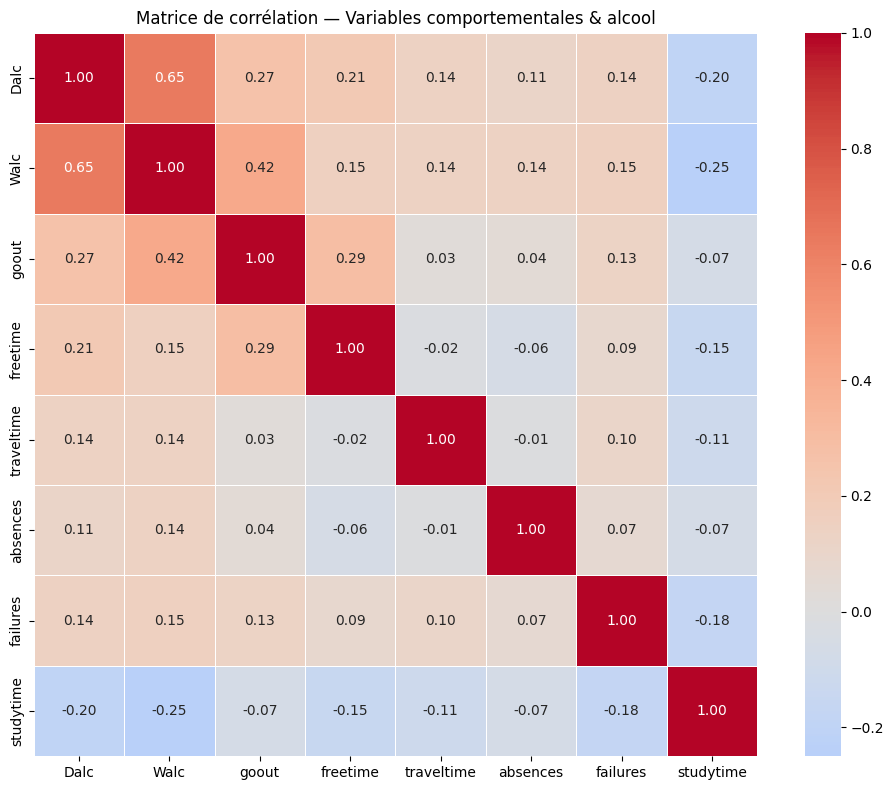

In [28]:
# ---- Matrice de corrélation ciblée alcool ----
cols_alcool = ['Dalc', 'Walc', 'goout', 'freetime', 
               'traveltime', 'absences', 'failures', 'studytime']

corr_alcool = student_mat_clean[cols_alcool].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_alcool,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Matrice de corrélation — Variables comportementales & alcool')
plt.tight_layout()
plt.show()

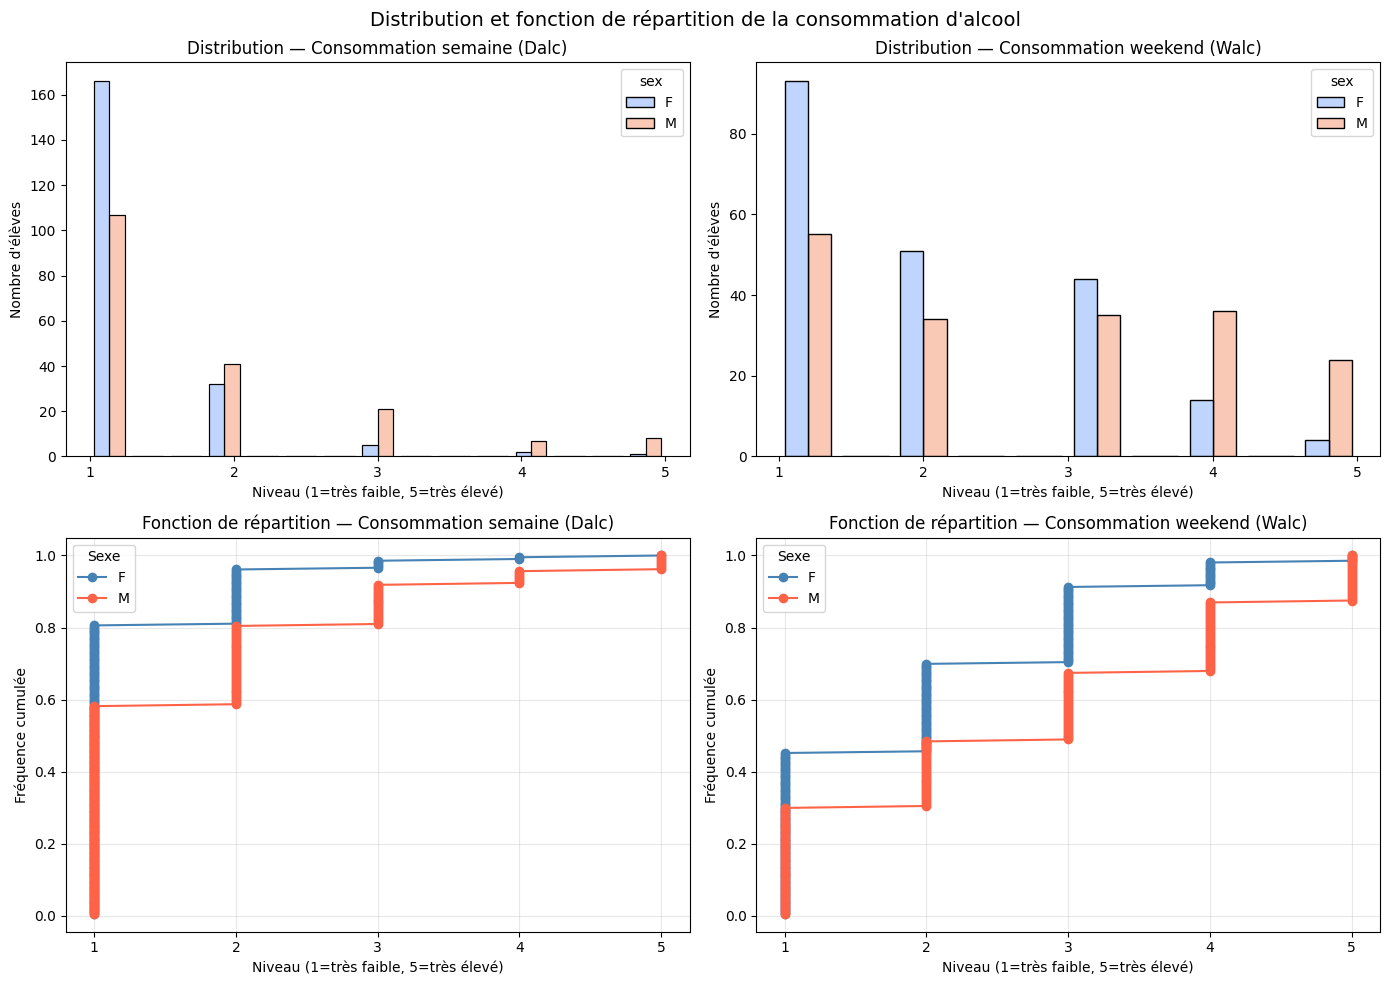

In [29]:
# ---- Histogrammes + CDF Dalc et Walc ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col_idx, (col, label) in enumerate(zip(['Dalc', 'Walc'],
                           ['Consommation semaine (Dalc)', 'Consommation weekend (Walc)'])):
    # Histogramme
    ax_hist = axes[0][col_idx]
    sns.histplot(data=student_mat_clean, x=col, hue='sex',
                 multiple='dodge', shrink=0.8, palette='coolwarm', ax=ax_hist)
    ax_hist.set_title(f'Distribution — {label}')
    ax_hist.set_xlabel(f'Niveau (1=très faible, 5=très élevé)')
    ax_hist.set_ylabel('Nombre d\'élèves')
    ax_hist.set_xticks([1, 2, 3, 4, 5])

    # CDF
    ax_cdf = axes[1][col_idx]
    for sex, color in zip(['F', 'M'], ['steelblue', 'tomato']):
        data_sex = student_mat_clean[student_mat_clean['sex'] == sex][col].sort_values()
        cdf = np.arange(1, len(data_sex) + 1) / len(data_sex)
        ax_cdf.plot(data_sex, cdf, marker='o', color=color, label=sex)
    
    ax_cdf.set_title(f'Fonction de répartition — {label}')
    ax_cdf.set_xlabel(f'Niveau (1=très faible, 5=très élevé)')
    ax_cdf.set_ylabel('Fréquence cumulée')
    ax_cdf.set_xticks([1, 2, 3, 4, 5])
    ax_cdf.legend(title='Sexe')
    ax_cdf.grid(True, alpha=0.3)

plt.suptitle('Distribution et fonction de répartition de la consommation d\'alcool', fontsize=14)
plt.tight_layout()
plt.show()

On va faire un score d'alcoolémie

```
score = Dalc * 2 + Walc
```

Ce qui donne un score de **3 à 15**, avec les classes :

| Classe | Score | Label |
|--------|-------|-------|
| 0 | 3 | Non-consommateur |
| 1 | 3-7 | Consommateur modéré |
| 2 | 8-15 | Consommateur régulier |


**Pourquoi ces seuils :**
- Le score 3 correspond à `Dalc=1, Walc=1` → vraiment aucune consommation
- Le score 4 c'est encore très faible (`Dalc=1, Walc=2` ou `Dalc=2, Walc=1` minimum)
- À partir de 8, ça représente une consommation vraiment significative en semaine

**Le problème potentiel :** la classe 2 sera assez petite (~60 élèves), ce qui peut poser des difficultés pour l'apprentissage supervisé ensuite.

Tu valides ces seuils ou tu veux les ajuster ?

In [30]:
# ---- Création des classes alcool ----
student_mat_clean['score_alcool'] = student_mat_clean['Dalc'] * 2 + student_mat_clean['Walc']

def classify_alcool(score):
    if score == 3:
        return 'Non-consommateur'
    elif score <= 7:
        return 'Modéré'
    else:
        return 'Régulier'

student_mat_clean['classe_alcool'] = student_mat_clean['score_alcool'].apply(classify_alcool)

# Vérification
print(student_mat_clean['classe_alcool'].value_counts())
print(student_mat_clean[['Dalc', 'Walc', 'score_alcool', 'classe_alcool']].head(10))


classe_alcool
Modéré              173
Non-consommateur    147
Régulier             70
Name: count, dtype: int64
   Dalc  Walc  score_alcool     classe_alcool
0     1     1             3  Non-consommateur
1     1     1             3  Non-consommateur
2     2     3             7            Modéré
3     1     1             3  Non-consommateur
4     1     2             4            Modéré
5     1     2             4            Modéré
6     1     1             3  Non-consommateur
7     1     1             3  Non-consommateur
8     1     1             3  Non-consommateur
9     1     1             3  Non-consommateur


On va voir sur les paramètre qu'on avait identifier avec la corrélation, l'impact sur les classes.

/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_40996/3095585700.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classe_alcool', y=col, data=student_mat_clean,
/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_40996/3095585700.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classe_alcool', y=col, data=student_mat_clean,
/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_40996/3095585700.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classe_alcool', y=col, data=student_mat_clean,
/var/folde

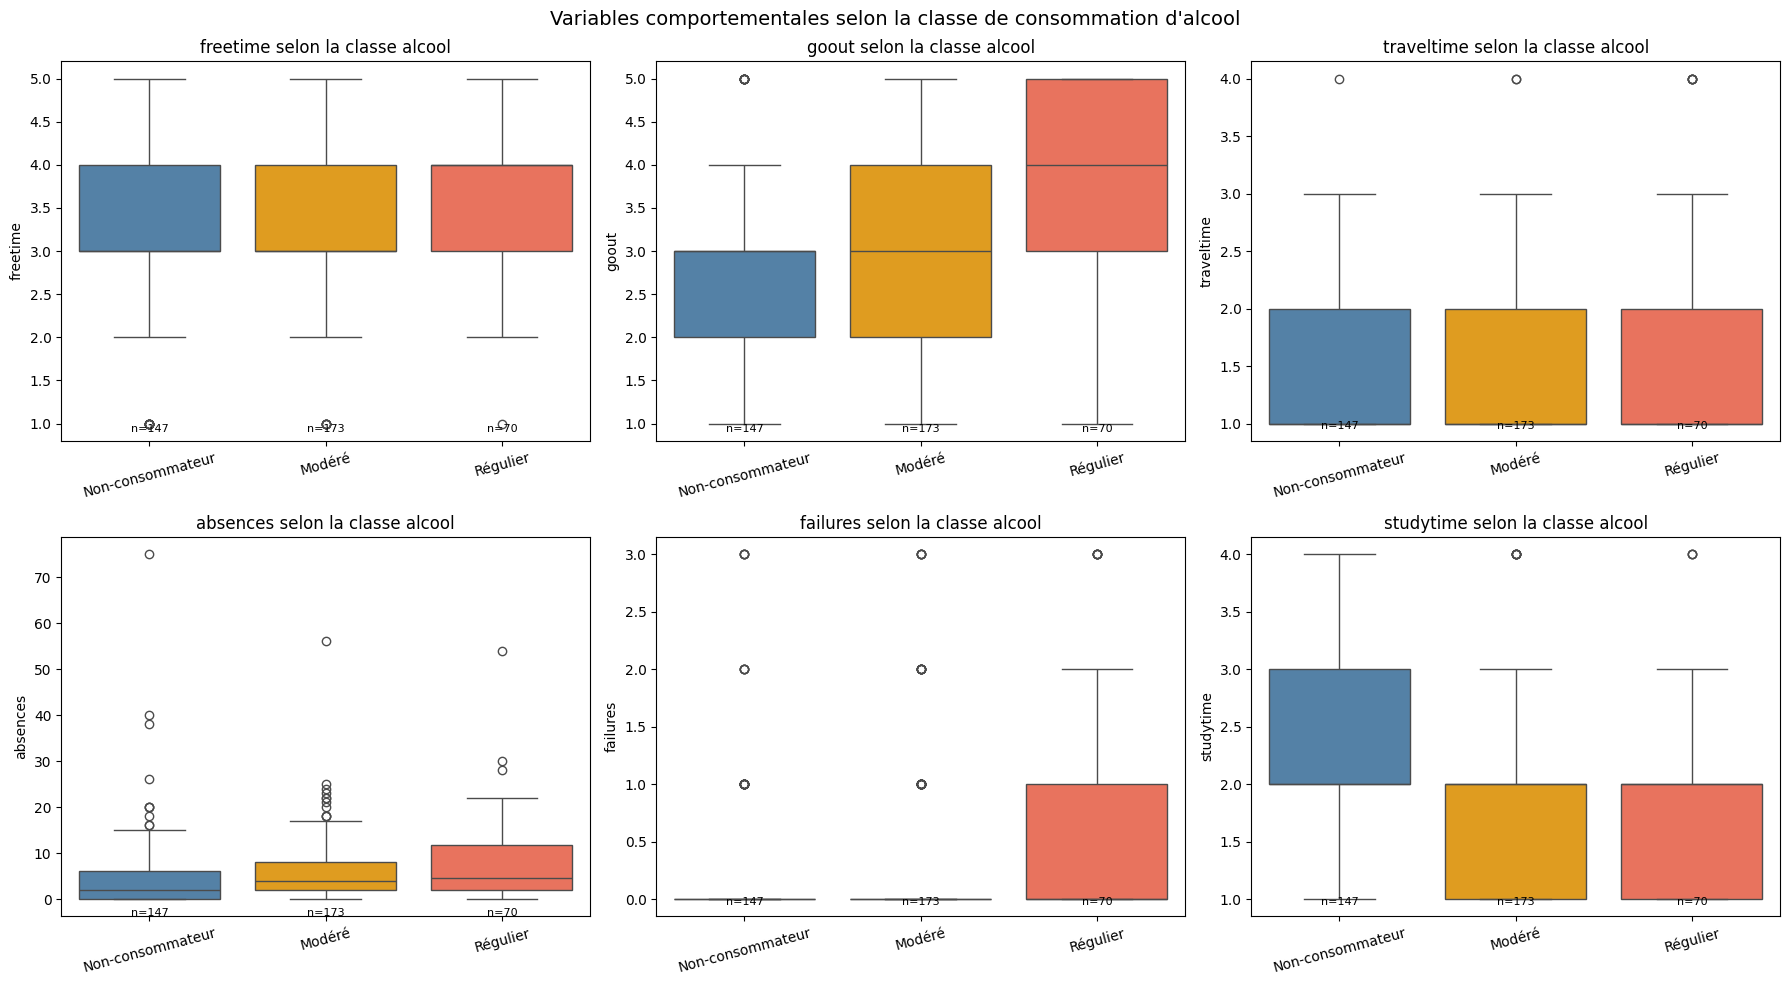

In [31]:
# ---- Boxplots classe_alcool vs variables comportementales ----
cols_comportement = ['freetime', 'goout', 'traveltime', 'absences', 'failures', 'studytime']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ordre = ['Non-consommateur', 'Modéré', 'Régulier']
palette = {'Non-consommateur': 'steelblue', 'Modéré': 'orange', 'Régulier': 'tomato'}

for ax, col in zip(axes.flatten(), cols_comportement):
    sns.boxplot(x='classe_alcool', y=col, data=student_mat_clean,
                order=ordre, palette=palette, ax=ax)
    
    # Effectifs
    counts = student_mat_clean['classe_alcool'].value_counts()
    for i, classe in enumerate(ordre):
        n = counts.get(classe, 0)
        ax.text(i, ax.get_ylim()[0] + 0.1, f'n={n}',
                ha='center', fontsize=8)
    
    ax.set_title(f'{col} selon la classe alcool')
    ax.set_xlabel('')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Variables comportementales selon la classe de consommation d\'alcool', fontsize=14)
plt.tight_layout()
plt.show()

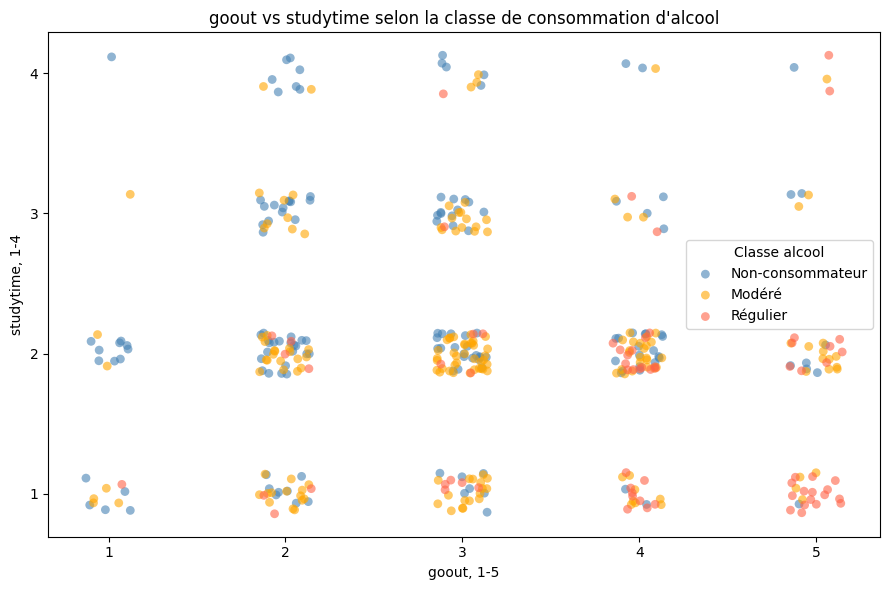

In [34]:
# ---- Scatterplot goout vs studytime par classe d'alcool ----
ordre = ['Non-consommateur', 'Modéré', 'Régulier']
palette = {'Non-consommateur': 'steelblue', 'Modéré': 'orange', 'Régulier': 'tomato'}

np.random.seed(42)
jitter = 0.15
x_jit = student_mat_clean['goout'] + np.random.uniform(-jitter, jitter, len(student_mat_clean))
y_jit = student_mat_clean['studytime'] + np.random.uniform(-jitter, jitter, len(student_mat_clean))

plt.figure(figsize=(9, 6))
for cls in ordre:
    mask = student_mat_clean['classe_alcool'] == cls
    plt.scatter(x_jit[mask], y_jit[mask],
                c=palette[cls], label=cls, alpha=0.6, s=40, edgecolors='none')

plt.xlabel('goout, 1-5')
plt.ylabel("studytime, 1-4")
plt.title("goout vs studytime selon la classe de consommation d'alcool")
plt.xticks([1, 2, 3, 4, 5])
plt.yticks([1, 2, 3, 4])
plt.legend(title='Classe alcool')
plt.tight_layout()
plt.show()


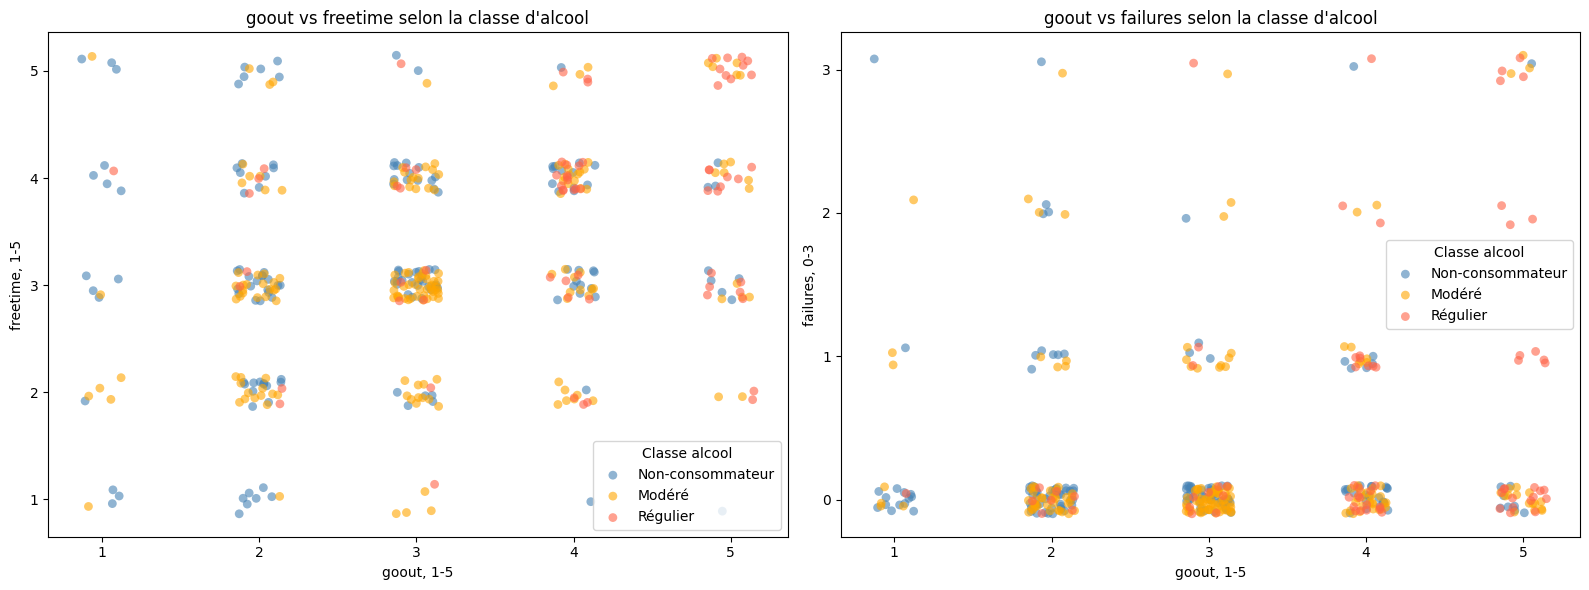

In [35]:
# ---- Scatterplots goout vs freetime et goout vs failures par classe d'alcool ----
ordre = ['Non-consommateur', 'Modéré', 'Régulier']
palette = {'Non-consommateur': 'steelblue', 'Modéré': 'orange', 'Régulier': 'tomato'}

np.random.seed(42)
jitter = 0.15

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- goout vs freetime ---
ax = axes[0]
x_jit = student_mat_clean['goout'] + np.random.uniform(-jitter, jitter, len(student_mat_clean))
y_jit = student_mat_clean['freetime'] + np.random.uniform(-jitter, jitter, len(student_mat_clean))
for cls in ordre:
    mask = student_mat_clean['classe_alcool'] == cls
    ax.scatter(x_jit[mask], y_jit[mask], c=palette[cls], label=cls, alpha=0.6, s=40, edgecolors='none')
ax.set_xlabel('goout, 1-5')
ax.set_ylabel('freetime, 1-5')
ax.set_title("goout vs freetime selon la classe d'alcool")
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5])
ax.legend(title='Classe alcool')

# --- goout vs failures ---
ax = axes[1]
np.random.seed(42)
x_jit = student_mat_clean['goout'] + np.random.uniform(-jitter, jitter, len(student_mat_clean))
y_jit = student_mat_clean['failures'] + np.random.uniform(-0.1, 0.1, len(student_mat_clean))
for cls in ordre:
    mask = student_mat_clean['classe_alcool'] == cls
    ax.scatter(x_jit[mask], y_jit[mask], c=palette[cls], label=cls, alpha=0.6, s=40, edgecolors='none')
ax.set_xlabel('goout, 1-5')
ax.set_ylabel("failures, 0-3")
ax.set_title("goout vs failures selon la classe d'alcool")
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks([0, 1, 2, 3])
ax.legend(title='Classe alcool')

plt.tight_layout()
plt.show()


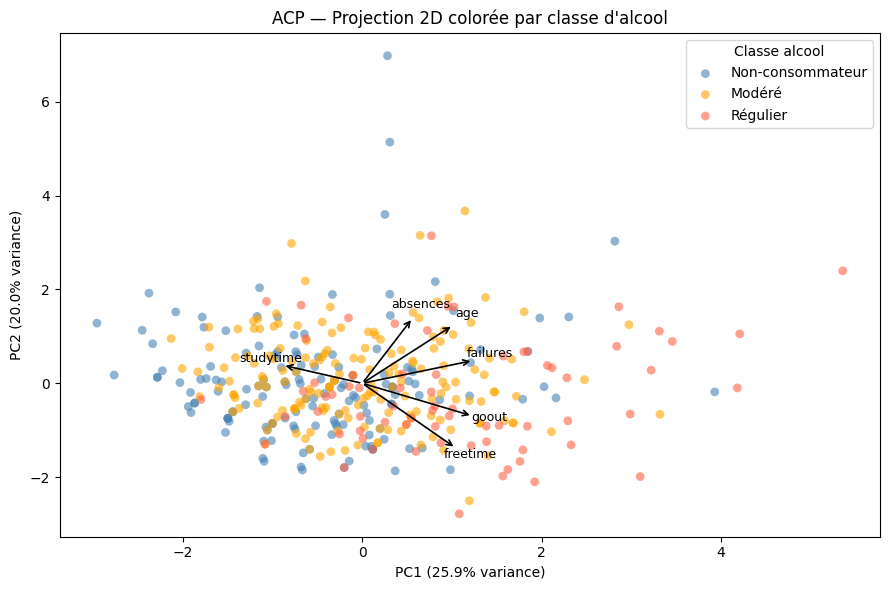

In [36]:
# ---- ACP : projection 2D de 6 variables comportementales ----
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

cols_features = ['goout', 'studytime', 'freetime', 'failures', 'absences', 'age']
ordre = ['Non-consommateur', 'Modéré', 'Régulier']
palette = {'Non-consommateur': 'steelblue', 'Modéré': 'orange', 'Régulier': 'tomato'}

X = student_mat_clean[cols_features].dropna()
idx = X.index
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
for cls in ordre:
    mask = student_mat_clean.loc[idx, 'classe_alcool'] == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=palette[cls], label=cls, alpha=0.6, s=40, edgecolors='none')

# Flèches des variables originales
loadings = pca.components_.T
scale = 2.5
for i, col in enumerate(cols_features):
    ax.annotate('', xy=(loadings[i,0]*scale, loadings[i,1]*scale), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
    ax.text(loadings[i,0]*scale*1.15, loadings[i,1]*scale*1.15, col, fontsize=9, ha='center')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title("ACP — Projection 2D colorée par classe d'alcool")
ax.legend(title='Classe alcool')
plt.tight_layout()
plt.show()


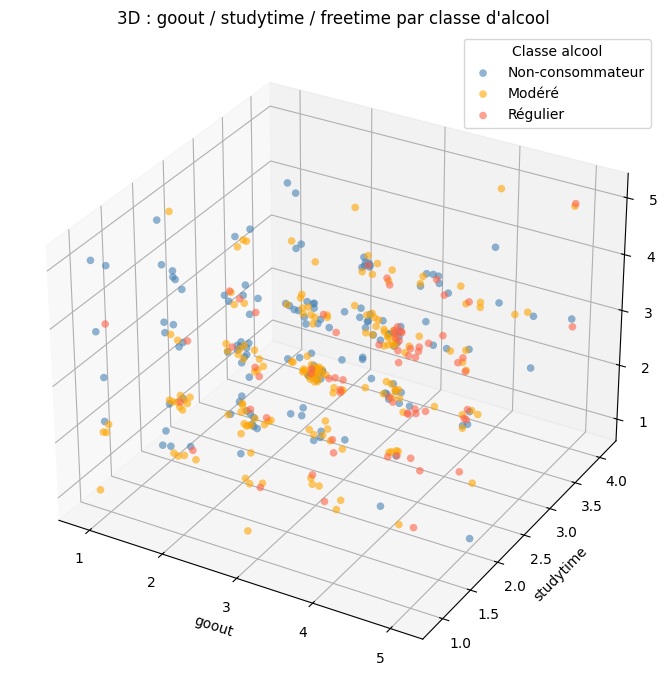

In [37]:
# ---- Scatterplot 3D : goout / studytime / freetime ----
from mpl_toolkits.mplot3d import Axes3D

ordre = ['Non-consommateur', 'Modéré', 'Régulier']
palette = {'Non-consommateur': 'steelblue', 'Modéré': 'orange', 'Régulier': 'tomato'}

np.random.seed(42)
jitter = 0.12

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for cls in ordre:
    mask = student_mat_clean['classe_alcool'] == cls
    sub = student_mat_clean[mask]
    x = sub['goout'] + np.random.uniform(-jitter, jitter, mask.sum())
    y = sub['studytime'] + np.random.uniform(-jitter, jitter, mask.sum())
    z = sub['freetime'] + np.random.uniform(-jitter, jitter, mask.sum())
    ax.scatter(x, y, z, c=palette[cls], label=cls, alpha=0.6, s=30, edgecolors='none')

ax.set_xlabel('goout')
ax.set_ylabel('studytime')
ax.set_zlabel('freetime')
ax.set_title("3D : goout / studytime / freetime par classe d'alcool")
ax.legend(title='Classe alcool')
plt.tight_layout()
plt.show()


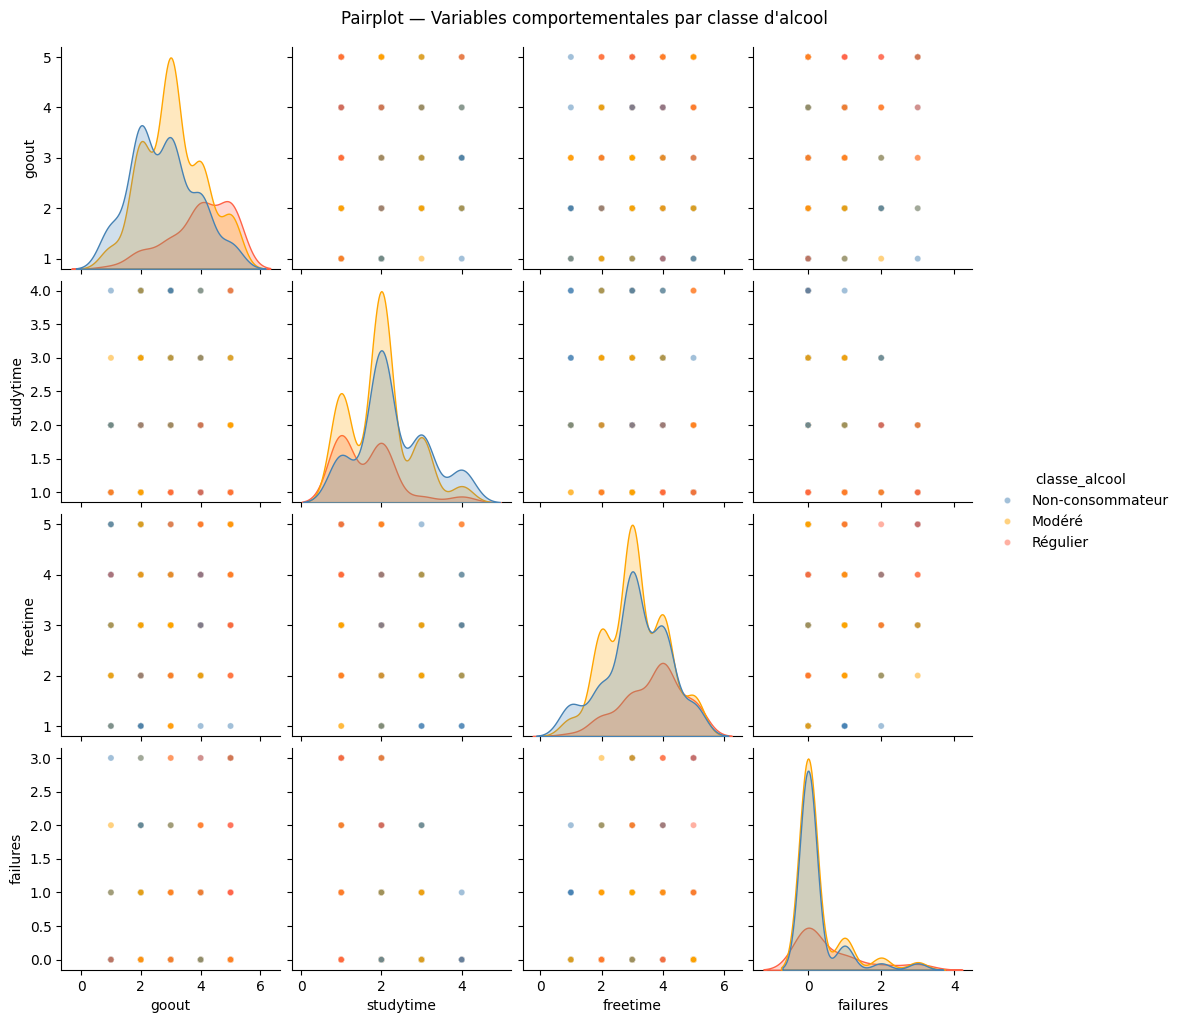

In [38]:
# ---- Pairplot : toutes les paires de variables comportementales ----
ordre = ['Non-consommateur', 'Modéré', 'Régulier']
palette = {'Non-consommateur': 'steelblue', 'Modéré': 'orange', 'Régulier': 'tomato'}

cols_pair = ['goout', 'studytime', 'freetime', 'failures']
df_pair = student_mat_clean[cols_pair + ['classe_alcool']].dropna()

g = sns.pairplot(df_pair, hue='classe_alcool', hue_order=ordre,
                 palette=palette, plot_kws={'alpha': 0.5, 's': 20}, diag_kind='kde')
g.fig.suptitle("Pairplot — Variables comportementales par classe d'alcool", y=1.02)
plt.show()


## Apprentissage Supervisée

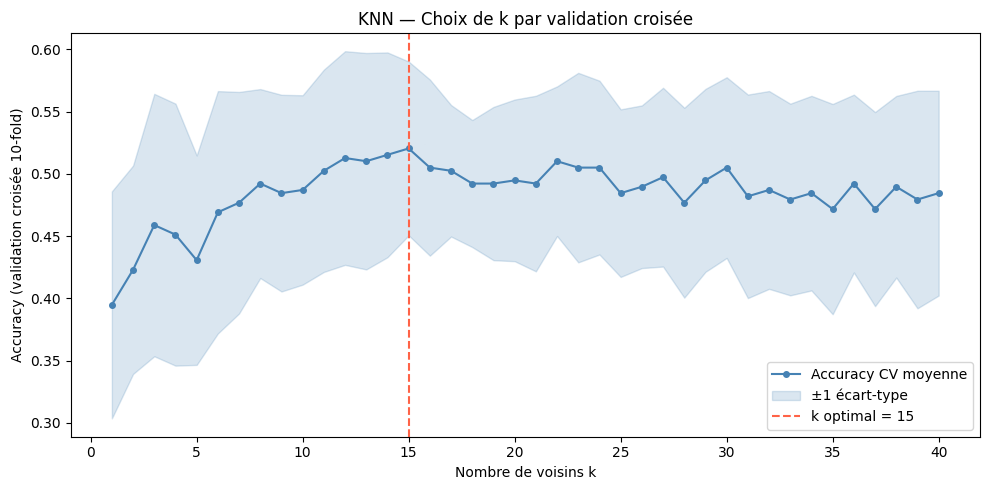

k optimal : 15
Accuracy  : 0.521 ± 0.070


In [39]:
# ---- Apprentissage supervisé : KNN avec validation croisée ----
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Préparation des données
cols_features = ['goout', 'studytime', 'freetime', 'failures', 'absences', 'age']
ordre_classes = ['Non-consommateur', 'Modéré', 'Régulier']

df_ml = student_mat_clean[cols_features + ['classe_alcool']].dropna().copy()
X = StandardScaler().fit_transform(df_ml[cols_features])
y = df_ml['classe_alcool'].values

# Validation croisée 10-fold pour chaque k
n_folds = 10
n_neighbors_list = range(1, 41)
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

results = []
for k in n_neighbors_list:
    clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(clf, X, y, cv=kf, scoring='accuracy')
    results.append({'k': k, 'accuracy': scores.mean(), 'std': scores.std()})

df_res = pd.DataFrame(results)
best_k = int(df_res.loc[df_res['accuracy'].idxmax(), 'k'])
best_acc = df_res['accuracy'].max()
best_std = df_res.loc[df_res['accuracy'].idxmax(), 'std']

# Courbe accuracy vs k
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_res['k'], df_res['accuracy'], 'o-', color='steelblue', markersize=4, label='Accuracy CV moyenne')
ax.fill_between(df_res['k'],
                df_res['accuracy'] - df_res['std'],
                df_res['accuracy'] + df_res['std'],
                alpha=0.2, color='steelblue', label='±1 écart-type')
ax.axvline(best_k, color='tomato', linestyle='--', label=f'k optimal = {best_k}')
ax.set_xlabel('Nombre de voisins k')
ax.set_ylabel('Accuracy (validation croisée 10-fold)')
ax.set_title('KNN — Choix de k par validation croisée')
ax.legend()
plt.tight_layout()
plt.show()

print(f"k optimal : {best_k}")
print(f"Accuracy  : {best_acc:.3f} ± {best_std:.3f}")


KNN (k=15)      — accuracy CV : 0.521 ± 0.070
LDA             — accuracy CV : 0.521 ± 0.057
QDA             — accuracy CV : 0.521 ± 0.089


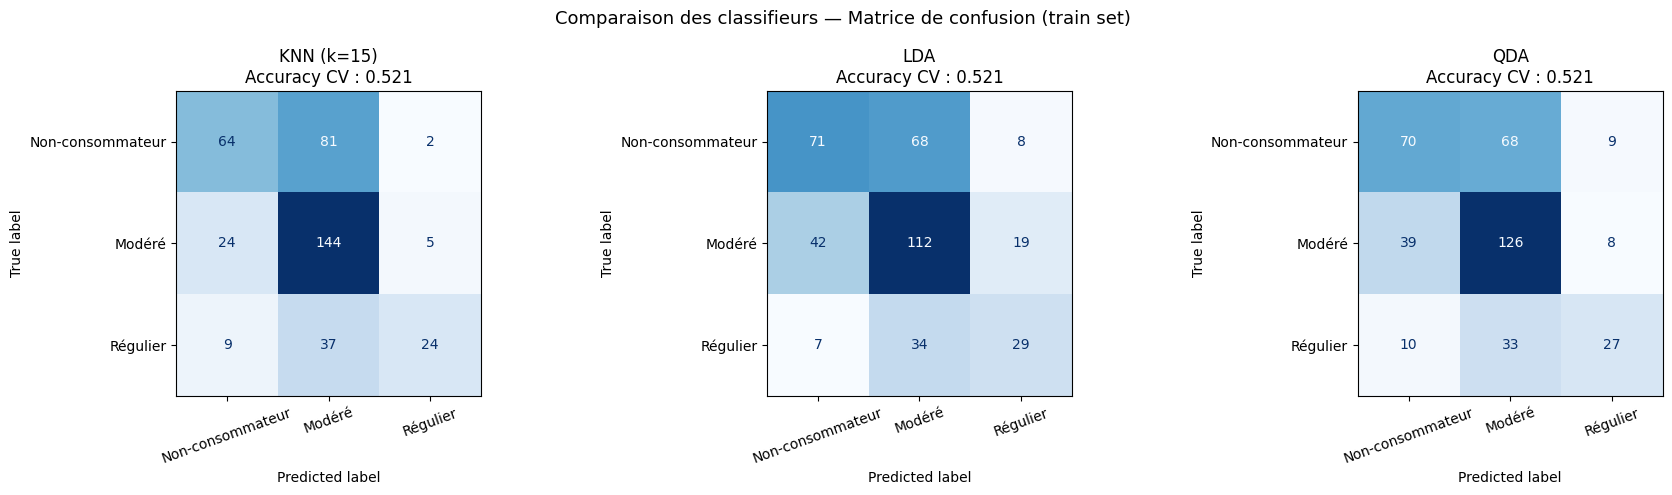

In [40]:
# ---- Comparaison KNN optimal vs LDA vs QDA + matrices de confusion ----
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models = {
    f'KNN (k={best_k})': KNeighborsClassifier(n_neighbors=best_k),
    'LDA'              : LinearDiscriminantAnalysis(),
    'QDA'              : QuadraticDiscriminantAnalysis(),
}

kf = KFold(n_splits=10, shuffle=True, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, clf) in zip(axes, models.items()):
    # Accuracy CV
    scores = cross_val_score(clf, X, y, cv=kf, scoring='accuracy')
    print(f"{name:15s} — accuracy CV : {scores.mean():.3f} ± {scores.std():.3f}")

    # Matrice de confusion (entraînement sur tout le jeu pour visualisation)
    clf.fit(X, y)
    y_pred = clf.predict(X)
    cm = confusion_matrix(y, y_pred, labels=ordre_classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordre_classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy CV : {scores.mean():.3f}')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Comparaison des classifieurs — Matrice de confusion (train set)', fontsize=13)
plt.tight_layout()
plt.show()


## Apprentissage supervisé sur Walc

In [ ]:
# ---- KNN avec validation croisée — cible : Walc (+ sex) ----
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

cols_features_walc = ['goout', 'studytime', 'freetime', 'failures', 'absences', 'age', 'Dalc', 'sex_M']

df_walc = student_mat_clean[['goout', 'studytime', 'freetime', 'failures', 'absences', 'age', 'Dalc', 'sex', 'Walc']].dropna().copy()
df_walc['sex_M'] = (df_walc['sex'] == 'M').astype(int)

X_walc = StandardScaler().fit_transform(df_walc[cols_features_walc])
y_walc = df_walc['Walc'].values

# Validation croisée 10-fold pour chaque k
n_folds = 10
n_neighbors_list = range(1, 41)
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

results_walc = []
for k in n_neighbors_list:
    clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(clf, X_walc, y_walc, cv=kf, scoring='accuracy')
    results_walc.append({'k': k, 'accuracy': scores.mean(), 'std': scores.std()})

df_res_walc = pd.DataFrame(results_walc)
best_k_walc = int(df_res_walc.loc[df_res_walc['accuracy'].idxmax(), 'k'])
best_acc_walc = df_res_walc['accuracy'].max()
best_std_walc = df_res_walc.loc[df_res_walc['accuracy'].idxmax(), 'std']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_res_walc['k'], df_res_walc['accuracy'], 'o-', color='steelblue', markersize=4, label='Accuracy CV moyenne')
ax.fill_between(df_res_walc['k'],
                df_res_walc['accuracy'] - df_res_walc['std'],
                df_res_walc['accuracy'] + df_res_walc['std'],
                alpha=0.2, color='steelblue', label='±1 écart-type')
ax.axvline(best_k_walc, color='tomato', linestyle='--', label=f'k optimal = {best_k_walc}')

naive_acc = (y_walc == 1).mean()
ax.axhline(naive_acc, color='gray', linestyle=':', label=f'Naïf (toujours Walc=1) : {naive_acc:.2f}')

ax.set_xlabel('Nombre de voisins k')
ax.set_ylabel('Accuracy (validation croisée 10-fold)')
ax.set_title('KNN — Choix de k par validation croisée (cible : Walc, avec sex)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"k optimal : {best_k_walc}")
print(f"Accuracy  : {best_acc_walc:.3f} ± {best_std_walc:.3f}")
print(f"Référence naïve : {naive_acc:.3f}")


ValueError: could not convert string to float: 'F'

KNN (k=16)           — accuracy CV : 0.713 ± 0.054
LDA                  — accuracy CV : 0.708 ± 0.053
QDA (reg=0.1)        — accuracy CV : 0.705 ± 0.053


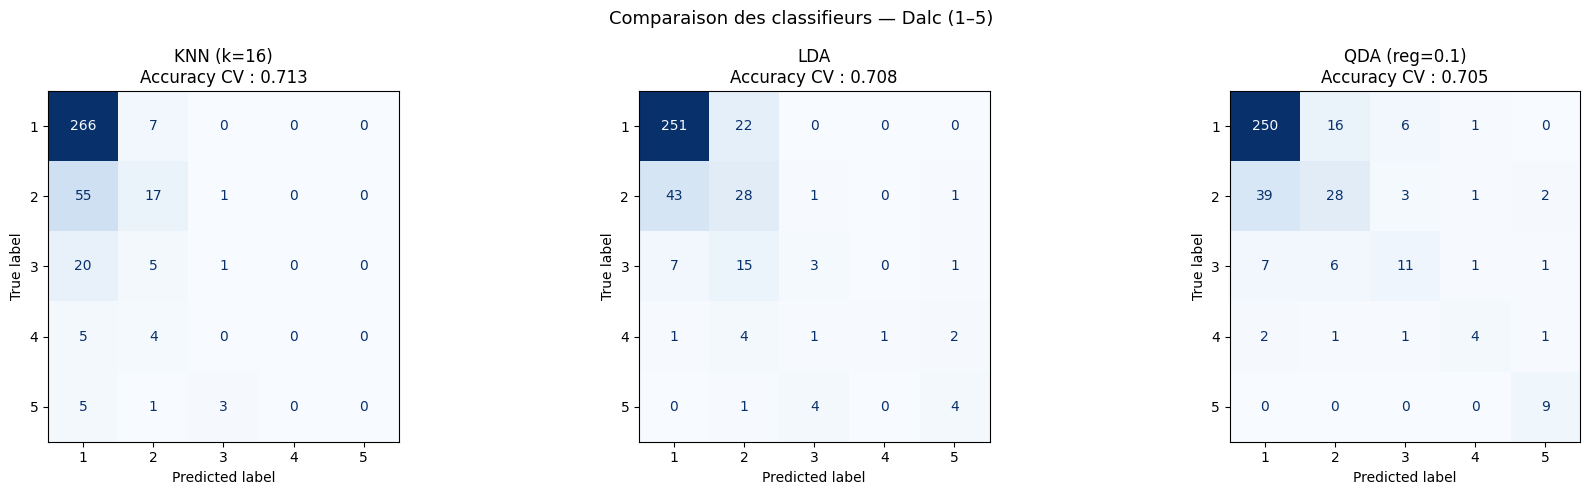

In [ ]:
# ---- Comparaison KNN / LDA / QDA — cible : Walc (avec sex) ----
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

classes_walc = [1, 2, 3, 4, 5]
models_walc = {
    f'KNN (k={best_k_walc})': KNeighborsClassifier(n_neighbors=best_k_walc),
    'LDA'                   : LinearDiscriminantAnalysis(),
    'QDA (reg=0.1)'         : QuadraticDiscriminantAnalysis(reg_param=0.1),
}

kf = KFold(n_splits=10, shuffle=True, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, clf) in zip(axes, models_walc.items()):
    scores = cross_val_score(clf, X_walc, y_walc, cv=kf, scoring='accuracy')
    print(f"{name:20s} — accuracy CV : {scores.mean():.3f} ± {scores.std():.3f}")
    clf.fit(X_walc, y_walc)
    y_pred = clf.predict(X_walc)
    cm = confusion_matrix(y_walc, y_pred, labels=classes_walc)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes_walc)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy CV : {scores.mean():.3f}')

plt.suptitle('Comparaison des classifieurs — Walc (1–5, avec sex)', fontsize=13)
plt.tight_layout()
plt.show()


## Apprentissage supervisé sur Dalc

In [ ]:
# ---- KNN avec validation croisée — cible : Dalc (avec sex) ----
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

cols_features_dalc = ['goout', 'studytime', 'freetime', 'failures', 'absences', 'age', 'Walc', 'sex_M']

df_dalc = student_mat_clean[['goout', 'studytime', 'freetime', 'failures', 'absences', 'age', 'Walc', 'sex', 'Dalc']].dropna().copy()
df_dalc['sex_M'] = (df_dalc['sex'] == 'M').astype(int)

X_dalc = StandardScaler().fit_transform(df_dalc[cols_features_dalc])
y_dalc = df_dalc['Dalc'].values

# Validation croisée 10-fold pour chaque k
kf = KFold(n_splits=10, shuffle=True, random_state=42)

results_dalc = []
for k in range(1, 41):
    clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(clf, X_dalc, y_dalc, cv=kf, scoring='accuracy')
    results_dalc.append({'k': k, 'accuracy': scores.mean(), 'std': scores.std()})

df_res_dalc = pd.DataFrame(results_dalc)
best_k_dalc = int(df_res_dalc.loc[df_res_dalc['accuracy'].idxmax(), 'k'])
best_acc_dalc = df_res_dalc['accuracy'].max()
best_std_dalc = df_res_dalc.loc[df_res_dalc['accuracy'].idxmax(), 'std']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_res_dalc['k'], df_res_dalc['accuracy'], 'o-', color='steelblue', markersize=4, label='Accuracy CV moyenne')
ax.fill_between(df_res_dalc['k'],
                df_res_dalc['accuracy'] - df_res_dalc['std'],
                df_res_dalc['accuracy'] + df_res_dalc['std'],
                alpha=0.2, color='steelblue', label='±1 écart-type')
ax.axvline(best_k_dalc, color='tomato', linestyle='--', label=f'k optimal = {best_k_dalc}')

naive_acc_dalc = (y_dalc == 1).mean()
ax.axhline(naive_acc_dalc, color='gray', linestyle=':', label=f'Naïf (toujours Dalc=1) : {naive_acc_dalc:.2f}')

ax.set_xlabel('Nombre de voisins k')
ax.set_ylabel('Accuracy (validation croisée 10-fold)')
ax.set_title('KNN — Choix de k par validation croisée (cible : Dalc, avec sex)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"k optimal : {best_k_dalc}")
print(f"Accuracy  : {best_acc_dalc:.3f} ± {best_std_dalc:.3f}")
print(f"Référence naïve : {naive_acc_dalc:.3f}")


In [ ]:
# ---- Comparaison KNN / LDA / LDA+shrinkage — cible : Dalc (avec sex) ----
# QDA inapplicable sur Dalc : classes 4 et 5 ont ~9 individus < 8 features
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

classes_dalc = [1, 2, 3, 4, 5]
models_dalc = {
    f'KNN (k={best_k_dalc})'  : KNeighborsClassifier(n_neighbors=best_k_dalc),
    'LDA'                     : LinearDiscriminantAnalysis(),
    'LDA + shrinkage (L-W)'   : LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto'),
}

kf = KFold(n_splits=10, shuffle=True, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, clf) in zip(axes, models_dalc.items()):
    scores = cross_val_score(clf, X_dalc, y_dalc, cv=kf, scoring='accuracy')
    print(f"{name:25s} — accuracy CV : {scores.mean():.3f} ± {scores.std():.3f}")
    clf.fit(X_dalc, y_dalc)
    y_pred = clf.predict(X_dalc)
    cm = confusion_matrix(y_dalc, y_pred, labels=classes_dalc)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes_dalc)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy CV : {scores.mean():.3f}')

naive_acc_dalc = (y_dalc == 1).mean()
print(f"{'Référence naïve':25s} — accuracy    : {naive_acc_dalc:.3f}")
plt.suptitle('Comparaison des classifieurs — Dalc (1–5, avec sex)', fontsize=13)
plt.tight_layout()
plt.show()


## Meilleure configuration : classe_alcool (3 classes) avec Dalc

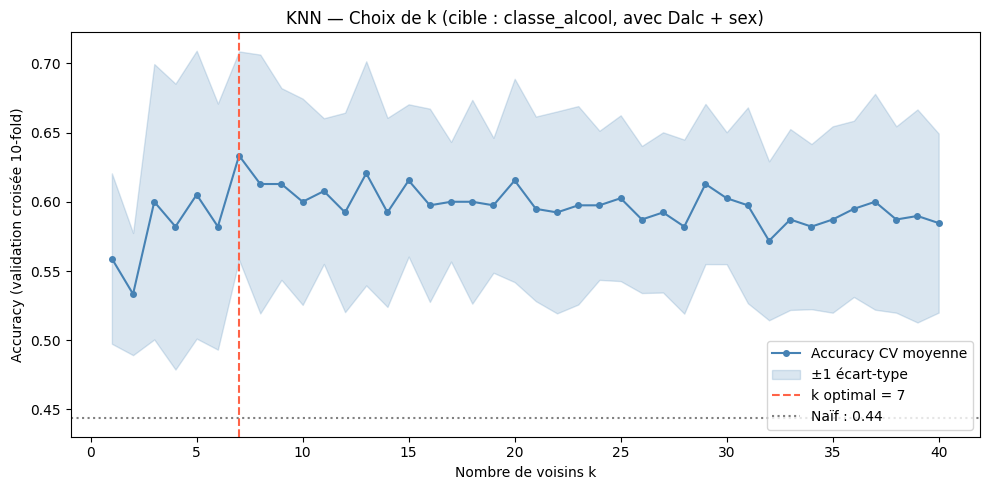

k optimal : 7
Accuracy  : 0.633 ± 0.075
Référence naïve : 0.444


In [56]:
# ---- KNN avec validation croisée — cible : classe_alcool, features : goout/studytime/freetime/failures/absences/age/Dalc/sex ----
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

cols_features_best = ['goout', 'studytime', 'freetime', 'failures', 'absences', 'age', 'Dalc', 'sex_M']
ordre_classes = ['Non-consommateur', 'Modéré', 'Régulier']

df_best = student_mat_clean[['goout', 'studytime', 'freetime', 'failures', 'absences', 'age', 'Dalc', 'sex', 'classe_alcool']].dropna().copy()
df_best['sex_M'] = (df_best['sex'] == 'M').astype(int)

X_best = StandardScaler().fit_transform(df_best[cols_features_best])
y_best = df_best['classe_alcool'].values

kf = KFold(n_splits=10, shuffle=True, random_state=42)

results_best = []
for k in range(1, 41):
    clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(clf, X_best, y_best, cv=kf, scoring='accuracy')
    results_best.append({'k': k, 'accuracy': scores.mean(), 'std': scores.std()})

df_res_best = pd.DataFrame(results_best)
best_k_best = int(df_res_best.loc[df_res_best['accuracy'].idxmax(), 'k'])
best_acc_best = df_res_best['accuracy'].max()
best_std_best = df_res_best.loc[df_res_best['accuracy'].idxmax(), 'std']

naive_acc_best = pd.Series(y_best).value_counts(normalize=True).max()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_res_best['k'], df_res_best['accuracy'], 'o-', color='steelblue', markersize=4, label='Accuracy CV moyenne')
ax.fill_between(df_res_best['k'],
                df_res_best['accuracy'] - df_res_best['std'],
                df_res_best['accuracy'] + df_res_best['std'],
                alpha=0.2, color='steelblue', label='±1 écart-type')
ax.axvline(best_k_best, color='tomato', linestyle='--', label=f'k optimal = {best_k_best}')
ax.axhline(naive_acc_best, color='gray', linestyle=':', label=f'Naïf : {naive_acc_best:.2f}')

ax.set_xlabel('Nombre de voisins k')
ax.set_ylabel('Accuracy (validation croisée 10-fold)')
ax.set_title("KNN — Choix de k (cible : classe_alcool, avec Dalc + sex)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"k optimal : {best_k_best}")
print(f"Accuracy  : {best_acc_best:.3f} ± {best_std_best:.3f}")
print(f"Référence naïve : {naive_acc_best:.3f}")


KNN (k=7)            — accuracy CV : 0.633 ± 0.075
LDA                  — accuracy CV : 0.682 ± 0.060
QDA (reg=0.1)        — accuracy CV : 0.674 ± 0.070


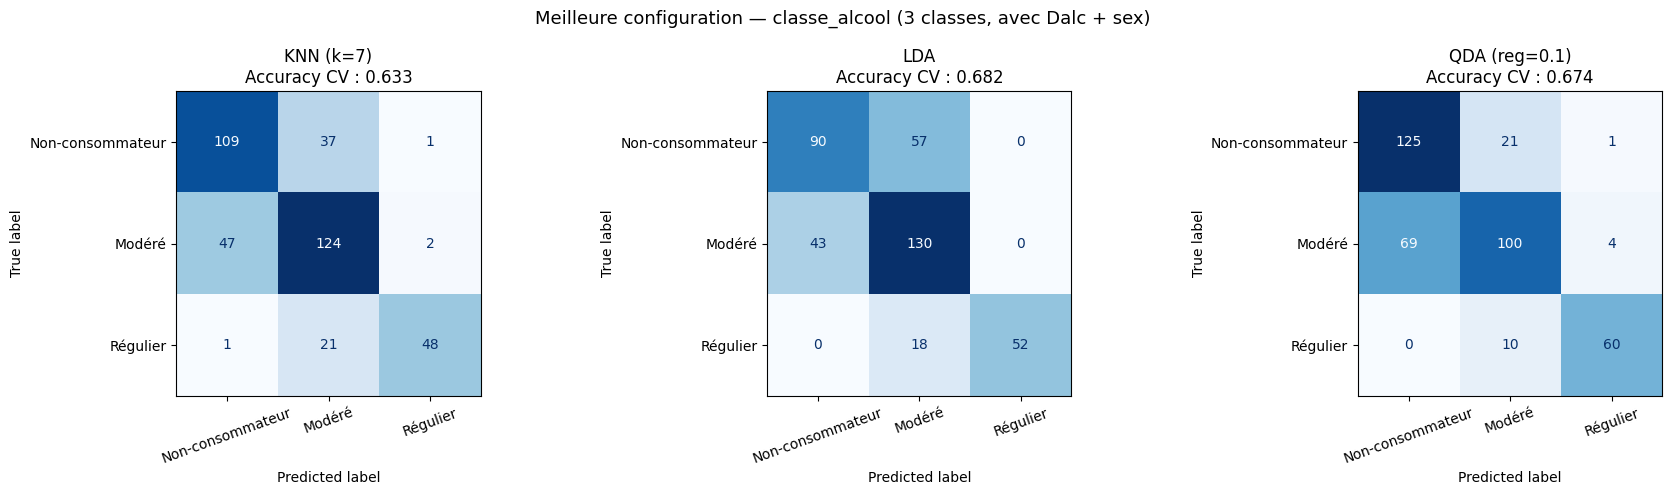

In [57]:
# ---- Comparaison KNN / LDA / QDA — cible : classe_alcool (avec Dalc + sex) ----
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ordre_classes = ['Non-consommateur', 'Modéré', 'Régulier']
models_best = {
    f'KNN (k={best_k_best})': KNeighborsClassifier(n_neighbors=best_k_best),
    'LDA'                   : LinearDiscriminantAnalysis(),
    'QDA (reg=0.1)'         : QuadraticDiscriminantAnalysis(reg_param=0.1),
}

kf = KFold(n_splits=10, shuffle=True, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, clf) in zip(axes, models_best.items()):
    scores = cross_val_score(clf, X_best, y_best, cv=kf, scoring='accuracy')
    print(f"{name:20s} — accuracy CV : {scores.mean():.3f} ± {scores.std():.3f}")
    clf.fit(X_best, y_best)
    y_pred = clf.predict(X_best)
    cm = confusion_matrix(y_best, y_pred, labels=ordre_classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordre_classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy CV : {scores.mean():.3f}')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle("Meilleure configuration — classe_alcool (3 classes, avec Dalc + sex)", fontsize=13)
plt.tight_layout()
plt.show()


## Prédiction de G3 (sans G1/G2) — alcool + comportement

In [58]:
# ---- Préparation : G3 en 3 classes, features comportementales + alcool ----
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Encodage
for col in ['schoolsup', 'higher']:
    student_mat_clean[col] = (student_mat_clean[col] == 'yes').astype(int)
student_mat_clean['sex_M'] = (student_mat_clean['sex'] == 'M').astype(int)

# Exclure G3=0 (absents/dispensés) et créer 3 classes
df_g3 = student_mat_clean[student_mat_clean['G3'] > 0].copy()
df_g3['G3_class'] = pd.cut(df_g3['G3'], bins=[0, 9, 13, 20],
                            labels=['Faible (0-9)', 'Moyen (10-13)', 'Bon (14-20)'])

print('Répartition des classes G3 :')
print(df_g3['G3_class'].value_counts().sort_index())

# Features significatives (p < 0.05, sans G1/G2)
cols_g3 = ['failures', 'Medu', 'absences', 'schoolsup', 'goout',
           'Walc', 'Dalc', 'age', 'Fedu', 'traveltime', 'studytime', 'higher']
ordre_g3 = ['Faible (0-9)', 'Moyen (10-13)', 'Bon (14-20)']

df_g3_clean = df_g3[cols_g3 + ['G3_class']].dropna()
X_g3 = StandardScaler().fit_transform(df_g3_clean[cols_g3])
y_g3 = df_g3_clean['G3_class'].values


Répartition des classes G3 :
G3_class
Faible (0-9)      91
Moyen (10-13)    164
Bon (14-20)       97
Name: count, dtype: int64


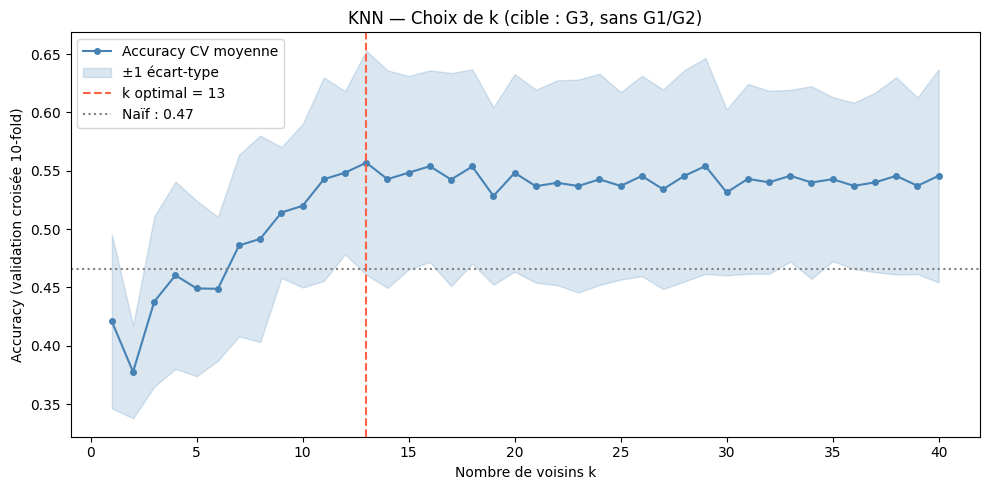

k optimal : 13
Accuracy  : 0.557 ± 0.096
Référence naïve : 0.466


In [59]:
# ---- KNN validation croisée — cible : G3 ----
kf = KFold(n_splits=10, shuffle=True, random_state=42)

results_g3 = []
for k in range(1, 41):
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_g3, y_g3, cv=kf, scoring='accuracy')
    results_g3.append({'k': k, 'accuracy': scores.mean(), 'std': scores.std()})

df_res_g3 = pd.DataFrame(results_g3)
best_k_g3 = int(df_res_g3.loc[df_res_g3['accuracy'].idxmax(), 'k'])
best_acc_g3 = df_res_g3['accuracy'].max()
best_std_g3 = df_res_g3.loc[df_res_g3['accuracy'].idxmax(), 'std']
naive_g3 = pd.Series(y_g3).value_counts(normalize=True).max()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_res_g3['k'], df_res_g3['accuracy'], 'o-', color='steelblue', markersize=4, label='Accuracy CV moyenne')
ax.fill_between(df_res_g3['k'],
                df_res_g3['accuracy'] - df_res_g3['std'],
                df_res_g3['accuracy'] + df_res_g3['std'],
                alpha=0.2, color='steelblue', label='±1 écart-type')
ax.axvline(best_k_g3, color='tomato', linestyle='--', label=f'k optimal = {best_k_g3}')
ax.axhline(naive_g3, color='gray', linestyle=':', label=f'Naïf : {naive_g3:.2f}')
ax.set_xlabel('Nombre de voisins k')
ax.set_ylabel('Accuracy (validation croisée 10-fold)')
ax.set_title('KNN — Choix de k (cible : G3, sans G1/G2)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"k optimal : {best_k_g3}")
print(f"Accuracy  : {best_acc_g3:.3f} ± {best_std_g3:.3f}")
print(f"Référence naïve : {naive_g3:.3f}")


KNN (k=13)           — accuracy CV : 0.557 ± 0.096
LDA                  — accuracy CV : 0.562 ± 0.095
QDA (reg=0.1)        — accuracy CV : 0.514 ± 0.080


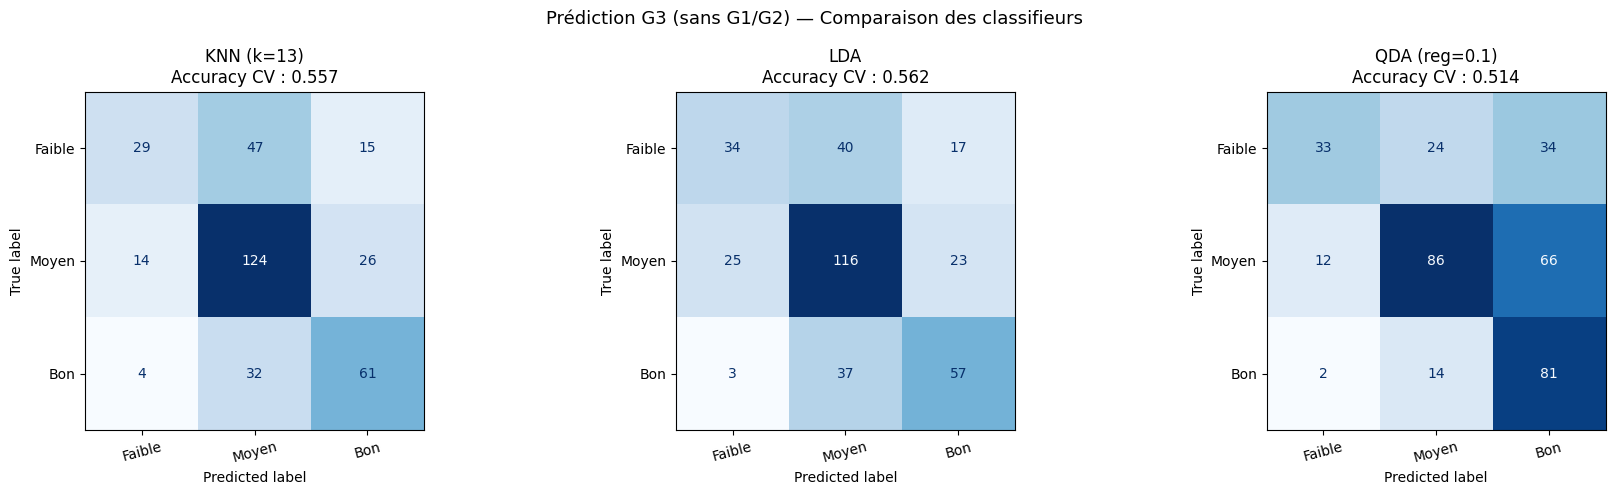


--- Impact de l'alcool sur la prédiction de G3 ---
  LDA Avec Walc+Dalc       : 0.562
  LDA Sans Walc/Dalc       : 0.511


In [60]:
# ---- Comparaison KNN / LDA / QDA + impact de l'alcool ----
kf = KFold(n_splits=10, shuffle=True, random_state=42)

models_g3 = {
    f'KNN (k={best_k_g3})': KNeighborsClassifier(n_neighbors=best_k_g3),
    'LDA'                 : LinearDiscriminantAnalysis(),
    'QDA (reg=0.1)'       : QuadraticDiscriminantAnalysis(reg_param=0.1),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, clf) in zip(axes, models_g3.items()):
    scores = cross_val_score(clf, X_g3, y_g3, cv=kf, scoring='accuracy')
    print(f"{name:20s} — accuracy CV : {scores.mean():.3f} ± {scores.std():.3f}")
    clf.fit(X_g3, y_g3)
    cm = confusion_matrix(y_g3, clf.predict(X_g3), labels=ordre_g3)
    ConfusionMatrixDisplay(cm, display_labels=['Faible', 'Moyen', 'Bon']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy CV : {scores.mean():.3f}')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Prédiction G3 (sans G1/G2) — Comparaison des classifieurs', fontsize=13)
plt.tight_layout()
plt.show()

# Impact de l'alcool : avec vs sans Walc/Dalc
print("\n--- Impact de l'alcool sur la prédiction de G3 ---")
cols_sans_alc = ['failures', 'Medu', 'absences', 'schoolsup', 'goout',
                 'age', 'Fedu', 'traveltime', 'studytime', 'higher']
X_sans = StandardScaler().fit_transform(df_g3_clean[cols_sans_alc])
for label, X_tmp in [('Avec Walc+Dalc', X_g3), ('Sans Walc/Dalc', X_sans)]:
    acc = cross_val_score(LinearDiscriminantAnalysis(), X_tmp, y_g3, cv=kf, scoring='accuracy').mean()
    print(f"  LDA {label:20s} : {acc:.3f}")


## Régression linéaire sur G3 (sans G1/G2)

In [61]:
# ---- Régression linéaire — cible : G3 (valeur continue) ----
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

cols_g3 = ['failures', 'Medu', 'absences', 'schoolsup', 'goout',
           'Walc', 'Dalc', 'age', 'Fedu', 'traveltime', 'studytime', 'higher']
cols_sans_alc = ['failures', 'Medu', 'absences', 'schoolsup', 'goout',
                 'age', 'Fedu', 'traveltime', 'studytime', 'higher']

# Exclure G3=0
df_reg = student_mat_clean[student_mat_clean['G3'] > 0].copy()
df_reg_clean = df_reg[cols_g3 + ['G3']].dropna()

X_reg = StandardScaler().fit_transform(df_reg_clean[cols_g3])
y_reg = df_reg_clean['G3'].values

kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Métriques CV
r2_scores  = cross_val_score(LinearRegression(), X_reg, y_reg, cv=kf, scoring='r2')
mse_scores = cross_val_score(LinearRegression(), X_reg, y_reg, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-mse_scores)

print(f"R²   moyen : {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")
print(f"RMSE moyen : {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f} points")
print(f"Baseline (prédire la moyenne) : RMSE = {y_reg.std():.2f}")

# Entraînement sur tout le jeu pour les coefficients
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_reg_clean[cols_g3])
reg = LinearRegression().fit(X_scaled, y_reg)

coefs = pd.Series(reg.coef_, index=cols_g3).sort_values(key=abs, ascending=False)
print(f"\nIntercept (note moyenne prédite) : {reg.intercept_:.2f}")
print("\nCoefficients standardisés (impact sur G3 en points par écart-type) :")
print(coefs.round(3).to_string())

# Impact de l'alcool
X_sans = StandardScaler().fit_transform(df_reg_clean[cols_sans_alc])
r2_sans = cross_val_score(LinearRegression(), X_sans, y_reg, cv=kf, scoring='r2').mean()
print(f"\nR² avec Walc+Dalc : {r2_scores.mean():.3f}")
print(f"R² sans  Walc/Dalc : {r2_sans:.3f}")
print(f"Apport alcool      : {(r2_scores.mean() - r2_sans):.3f}")


R²   moyen : 0.094 ± 0.090
RMSE moyen : 3.02 ± 0.23 points
Baseline (prédire la moyenne) : RMSE = 3.22

Intercept (note moyenne prédite) : 11.50

Coefficients standardisés (impact sur G3 en points par écart-type) :
Medu          0.594
failures     -0.593
absences     -0.556
goout        -0.386
studytime     0.201
Walc         -0.168
traveltime   -0.071
Dalc         -0.039
Fedu          0.017
age          -0.003
schoolsup     0.000
higher        0.000

R² avec Walc+Dalc : 0.094
R² sans  Walc/Dalc : 0.101
Apport alcool      : -0.007


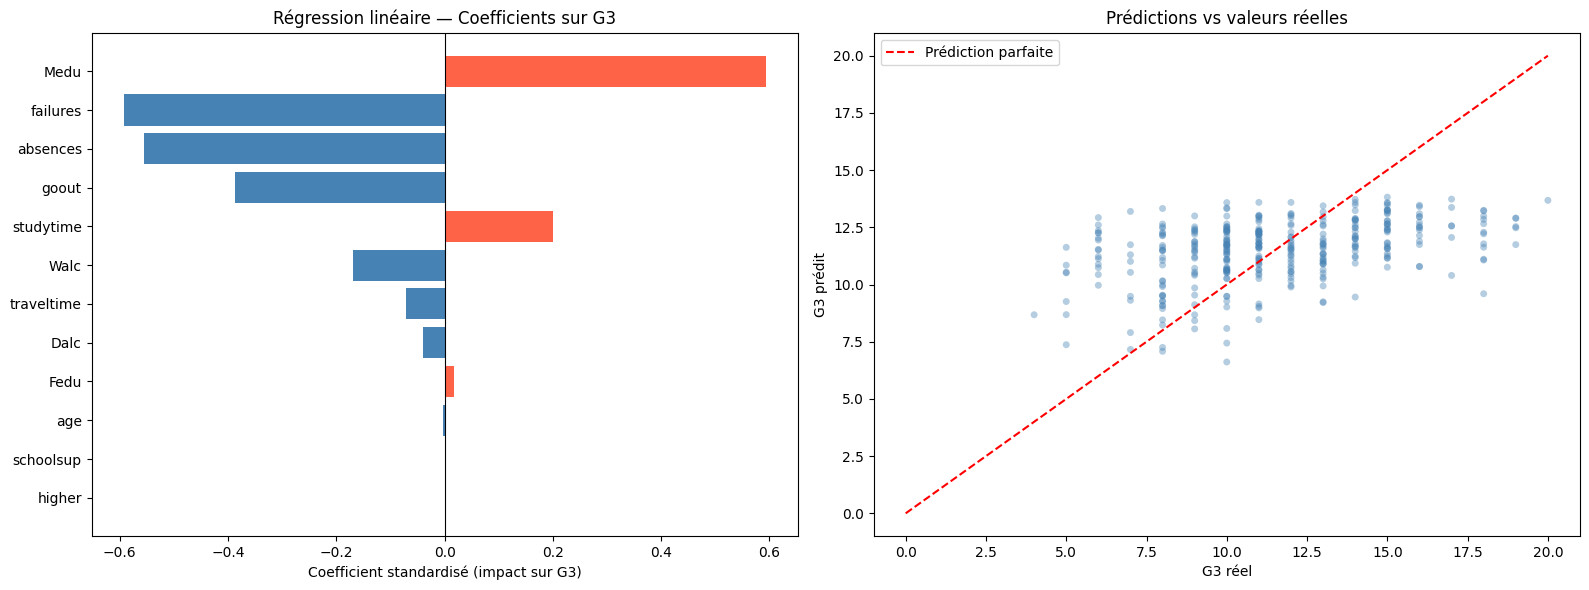

In [62]:
# ---- Visualisation : coefficients + prédictions vs réel ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphe 1 : coefficients standardisés
colors = ['tomato' if v > 0 else 'steelblue' for v in coefs.values]
axes[0].barh(coefs.index[::-1], coefs.values[::-1], color=colors[::-1])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Coefficient standardisé (impact sur G3)')
axes[0].set_title('Régression linéaire — Coefficients sur G3')

# Graphe 2 : valeurs prédites vs réelles
y_pred = reg.predict(X_scaled)
axes[1].scatter(y_reg, y_pred, alpha=0.4, s=25, color='steelblue', edgecolors='none')
axes[1].plot([0, 20], [0, 20], 'r--', linewidth=1.5, label='Prédiction parfaite')
axes[1].set_xlabel('G3 réel'); axes[1].set_ylabel('G3 prédit')
axes[1].set_title('Prédictions vs valeurs réelles')
axes[1].legend()

plt.tight_layout()
plt.show()


Conclusion honnête : sans G1/G2, G3 est difficile à prédire. Les facteurs socio-familiaux et comportementaux n'expliquent que ~16% de la note finale — le reste vient de la capacité intrinsèque de l'élève, qu'on ne mesure pas dans ce dataset.

## Clustering non-supervisé — K-means

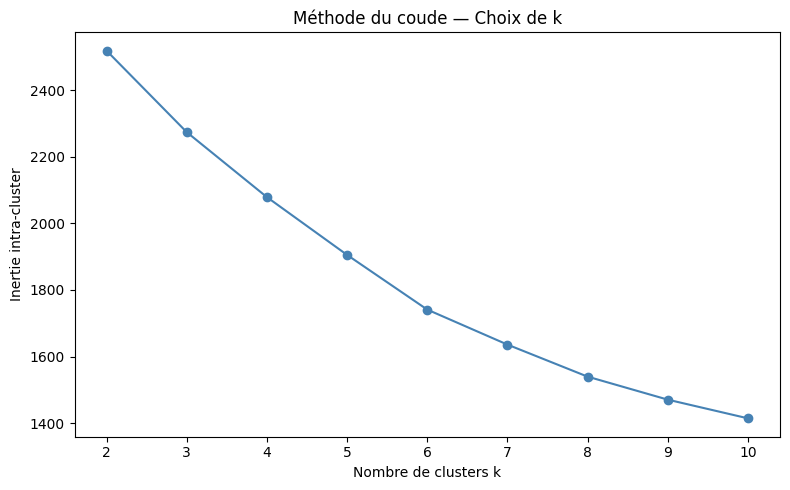

In [68]:
# ---- Choix du nombre de clusters : méthode du coude (inertie) ----
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cols_clust = ['goout', 'studytime', 'freetime', 'failures', 'absences', 'Walc', 'Dalc', 'age']

df_clust = student_mat_clean[cols_clust].dropna().copy()
X_clust = StandardScaler().fit_transform(df_clust)

n_clusters_list = range(2, 11)
inertias = []
for k in n_clusters_list:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_clust)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(n_clusters_list), inertias, 'o-', color='steelblue')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie intra-cluster')
plt.title('Méthode du coude — Choix de k')
plt.xticks(list(n_clusters_list))
plt.tight_layout()
plt.show()


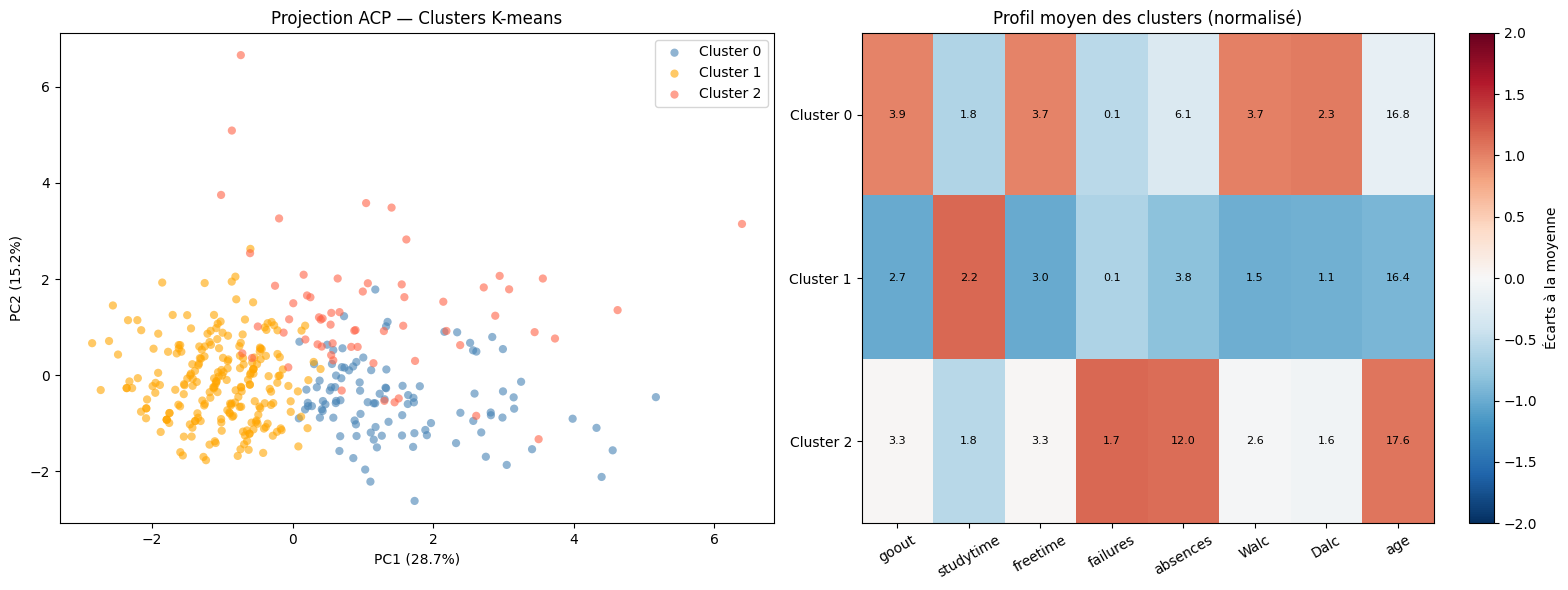

Taille des clusters :
cluster
0    105
1    223
2     62
Name: count, dtype: int64


In [69]:
# ---- K-means avec k optimal + visualisation ACP ----
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

k_opt = 3  # ajuster selon la courbe silhouette

km = KMeans(n_clusters=k_opt, n_init=50, random_state=42)
df_clust['cluster'] = km.fit_predict(X_clust)

# Projection ACP 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clust)

palette_clust = {0: 'steelblue', 1: 'orange', 2: 'tomato'}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter par cluster
for c in range(k_opt):
    mask = df_clust['cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=palette_clust[c], label=f'Cluster {c}', alpha=0.6, s=35, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Projection ACP — Clusters K-means')
axes[0].legend()

# Profil moyen de chaque cluster (heatmap)
profile = df_clust.groupby('cluster')[cols_clust].mean()
profile_norm = (profile - profile.mean()) / profile.std()
im = axes[1].imshow(profile_norm.values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
axes[1].set_xticks(range(len(cols_clust))); axes[1].set_xticklabels(cols_clust, rotation=30)
axes[1].set_yticks(range(k_opt)); axes[1].set_yticklabels([f'Cluster {i}' for i in range(k_opt)])
axes[1].set_title('Profil moyen des clusters (normalisé)')
plt.colorbar(im, ax=axes[1], label='Écarts à la moyenne')

# Valeurs dans les cases
for i in range(k_opt):
    for j in range(len(cols_clust)):
        axes[1].text(j, i, f'{profile.values[i,j]:.1f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("Taille des clusters :")
print(df_clust['cluster'].value_counts().sort_index())


In [70]:
# ---- Comparaison clusters K-means vs classe_alcool ----
df_comp = df_clust.copy()
df_comp.index = student_mat_clean[cols_clust].dropna().index
df_comp['classe_alcool'] = student_mat_clean.loc[df_comp.index, 'classe_alcool']

crosstab = pd.crosstab(df_comp['cluster'], df_comp['classe_alcool'],
                       margins=True, margins_name='Total')
print("Tableau croisé Cluster × classe_alcool :")
print(crosstab)

# Version pourcentage (par cluster)
crosstab_pct = pd.crosstab(df_comp['cluster'], df_comp['classe_alcool'], normalize='index') * 100
print("\nPourcentage par cluster :")
print(crosstab_pct.round(1))


Tableau croisé Cluster × classe_alcool :
classe_alcool  Modéré  Non-consommateur  Régulier  Total
cluster                                                 
0                  50                 0        55    105
1                  93               130         0    223
2                  30                17        15     62
Total             173               147        70    390

Pourcentage par cluster :
classe_alcool  Modéré  Non-consommateur  Régulier
cluster                                          
0                47.6               0.0      52.4
1                41.7              58.3       0.0
2                48.4              27.4      24.2
